In [1]:
from shared.main import *

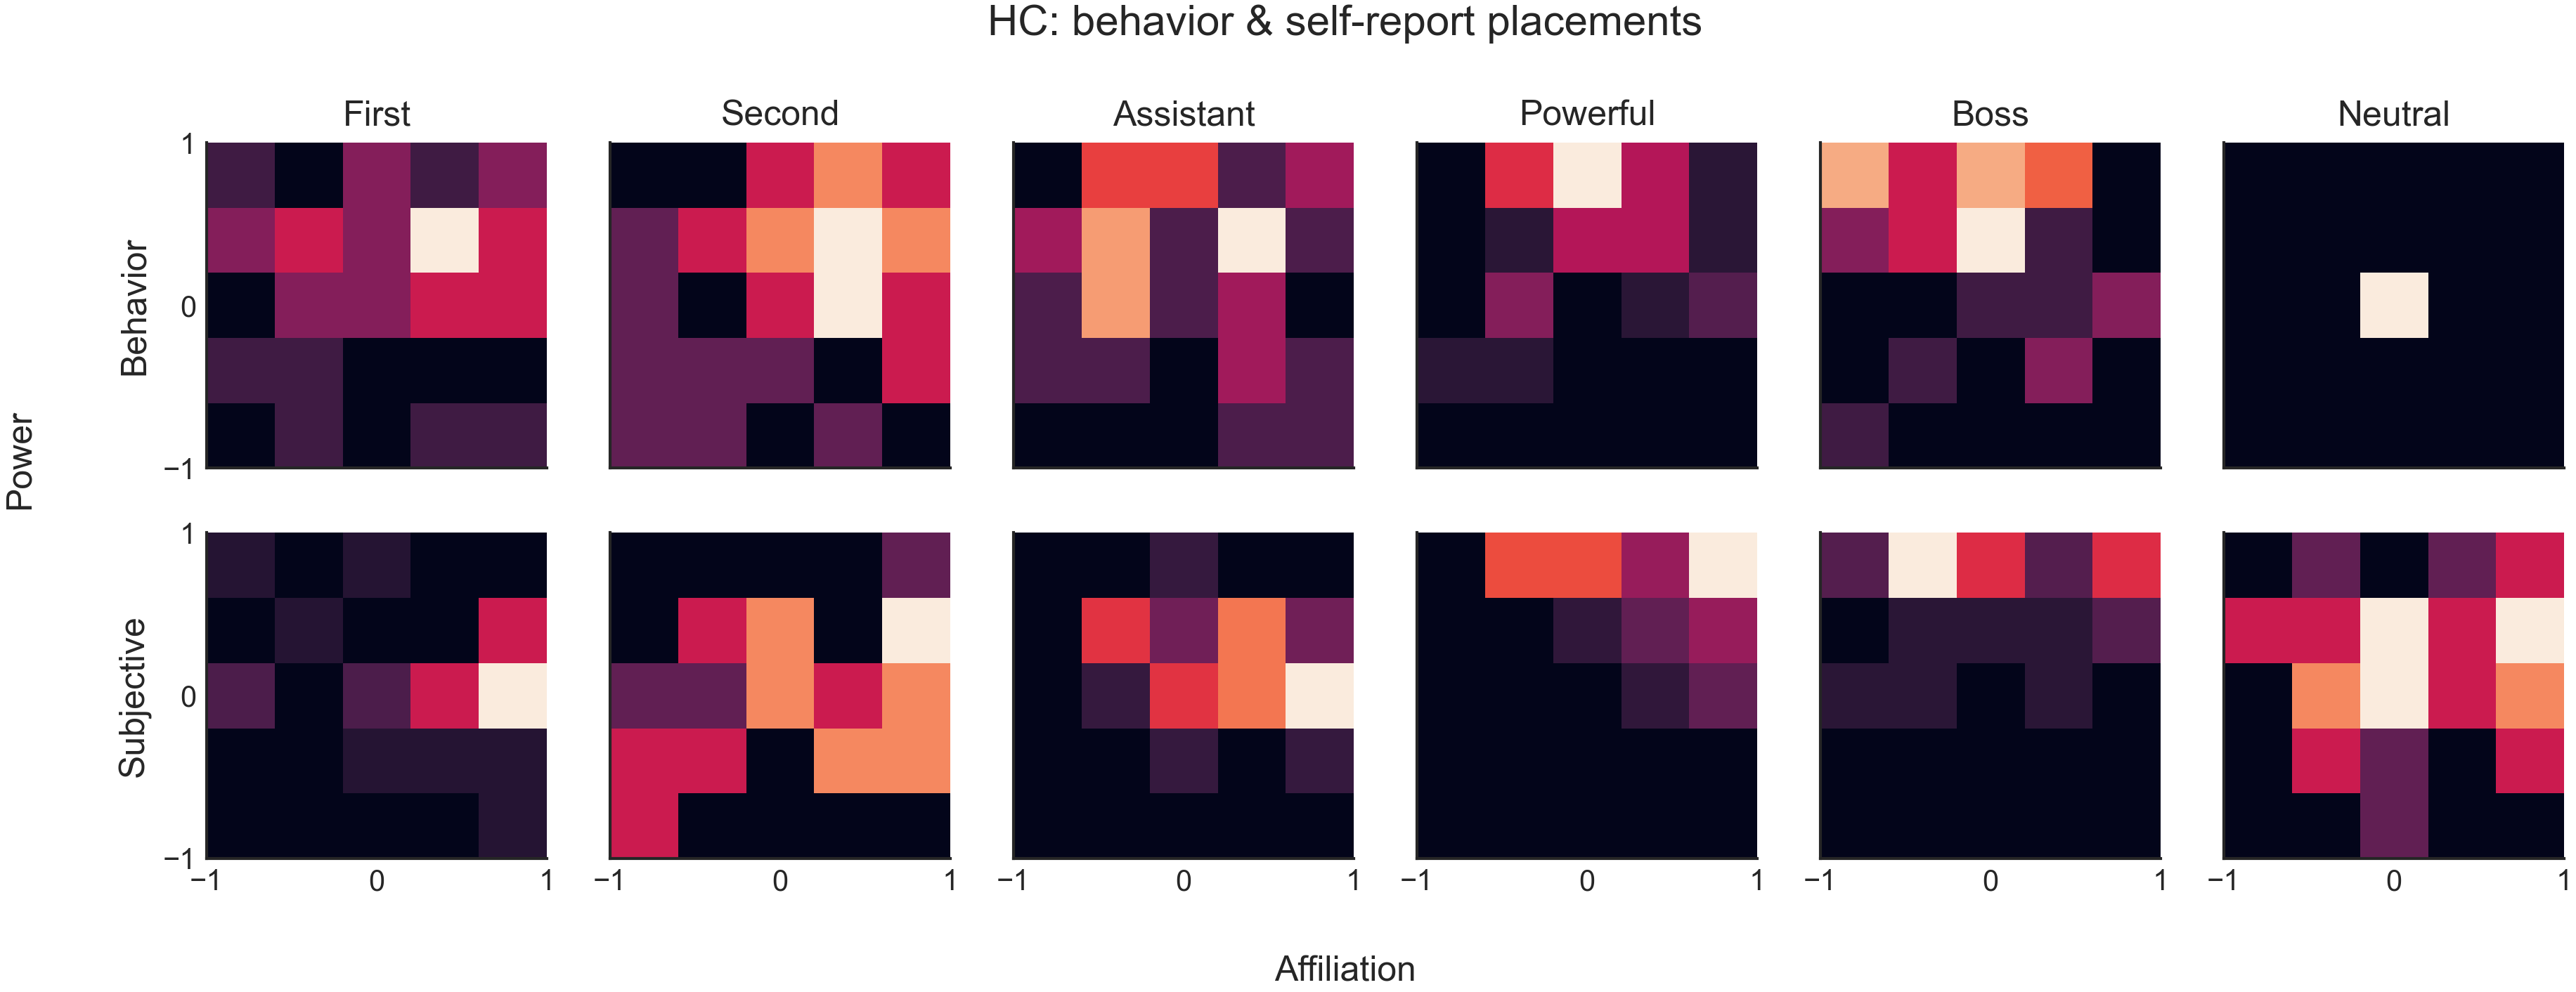

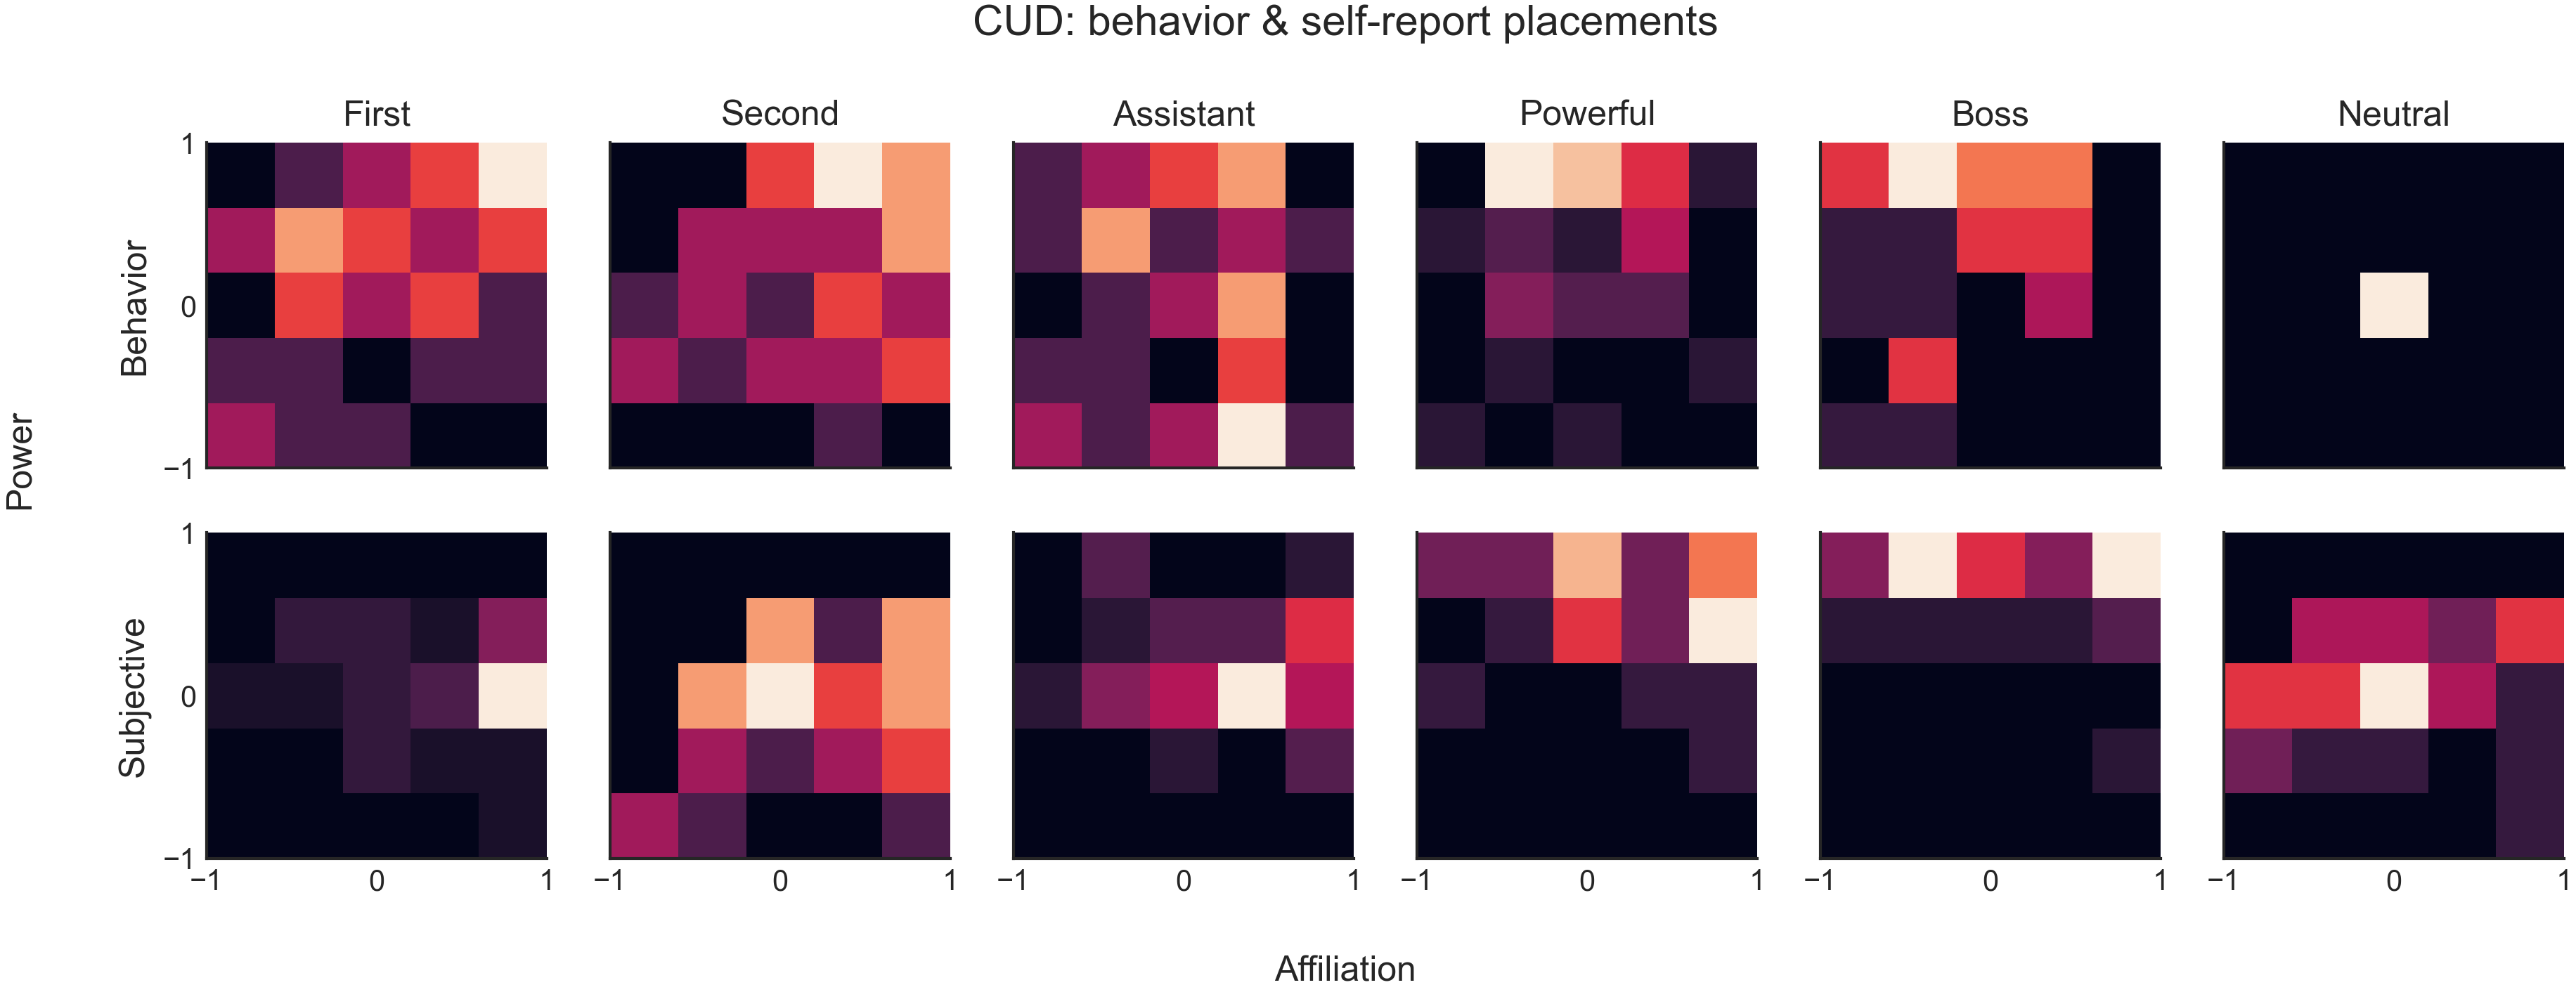

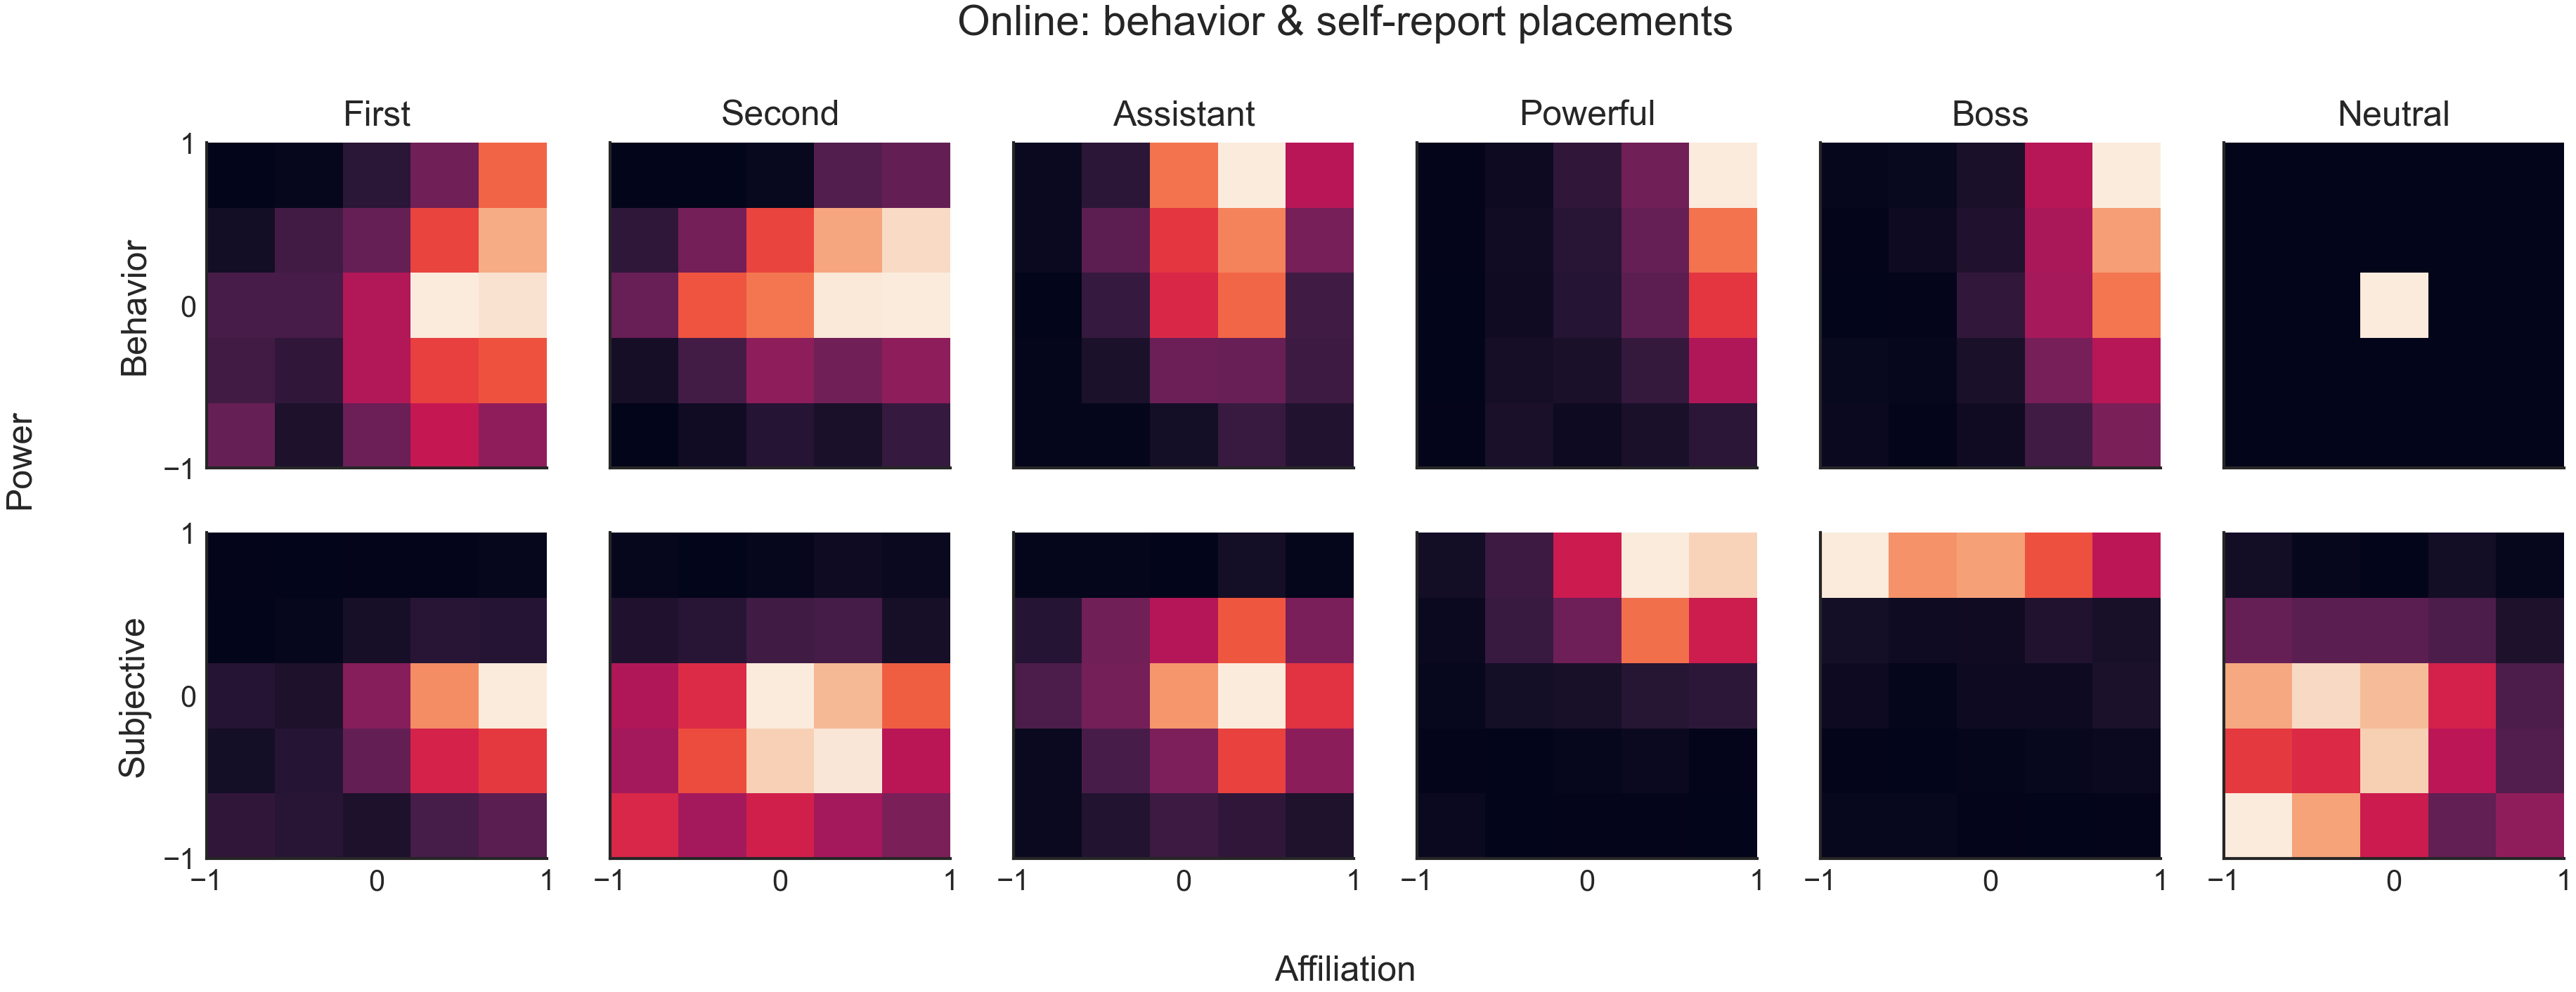

In [2]:
norm_binedges = np.array([-1, -0.6, -0.2, 0.2, 0.6, 1])

def plot_behavior_and_subjective(df, title, characters):
    fig, axs = plt.subplots(2, 6, figsize=(12, 4.5), sharex=True, sharey=True)
    fig.subplots_adjust(top=0.95)
    fig.suptitle(title)
    fig.text(0.5, -0.05, 'Affiliation', ha='center')
    fig.text(-0.03, 0.5, 'Power', va='center', rotation='vertical')

    for c, char in enumerate(characters):
        axs[0, c].set_title(char.capitalize())

        # behavior placements
        task_affil = df[f'affil_mean_{char}']
        task_power = df[f'power_mean_{char}']
        axs[0, c].hist2d(task_affil, task_power,
                         bins=[norm_binedges, norm_binedges])
        axs[0, c].set_ylabel('Behavior')
        axs[0, c].set_yticks([-1, 0, 1])
        axs[0, c].set_xticks([-1, 0, 1])

        # subjective placements
        dots_power = df[f'power_subj_{char}']
        dots_affil = df[f'affil_subj_{char}']
        axs[1, c].hist2d(dots_affil, dots_power,
                         bins=[norm_binedges, norm_binedges])
        axs[1, c].set_ylabel('Subjective')
        axs[1, c].set_yticks([-1, 0, 1])
        axs[1, c].set_xticks([-1, 0, 1])

        # hide repeated y-axes for columns > 0
        if c > 0:
            for r in range(2):
                axs[r, c].axes.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# 1) Plots by dx as before
for dx in [0, 1]:
    data_ = data[data['dx'] == dx]
    plot_behavior_and_subjective(
        data_,
        title=f'{["HC","CUD"][dx]}: behavior & self-report placements',
        characters=CHARACTERS
    )

# 2) Online data (no dx split, single set of plots)
plot_behavior_and_subjective(
    data_online,
    title='Online: behavior & self-report placements',
    characters=CHARACTERS
)


## Mapping relationships

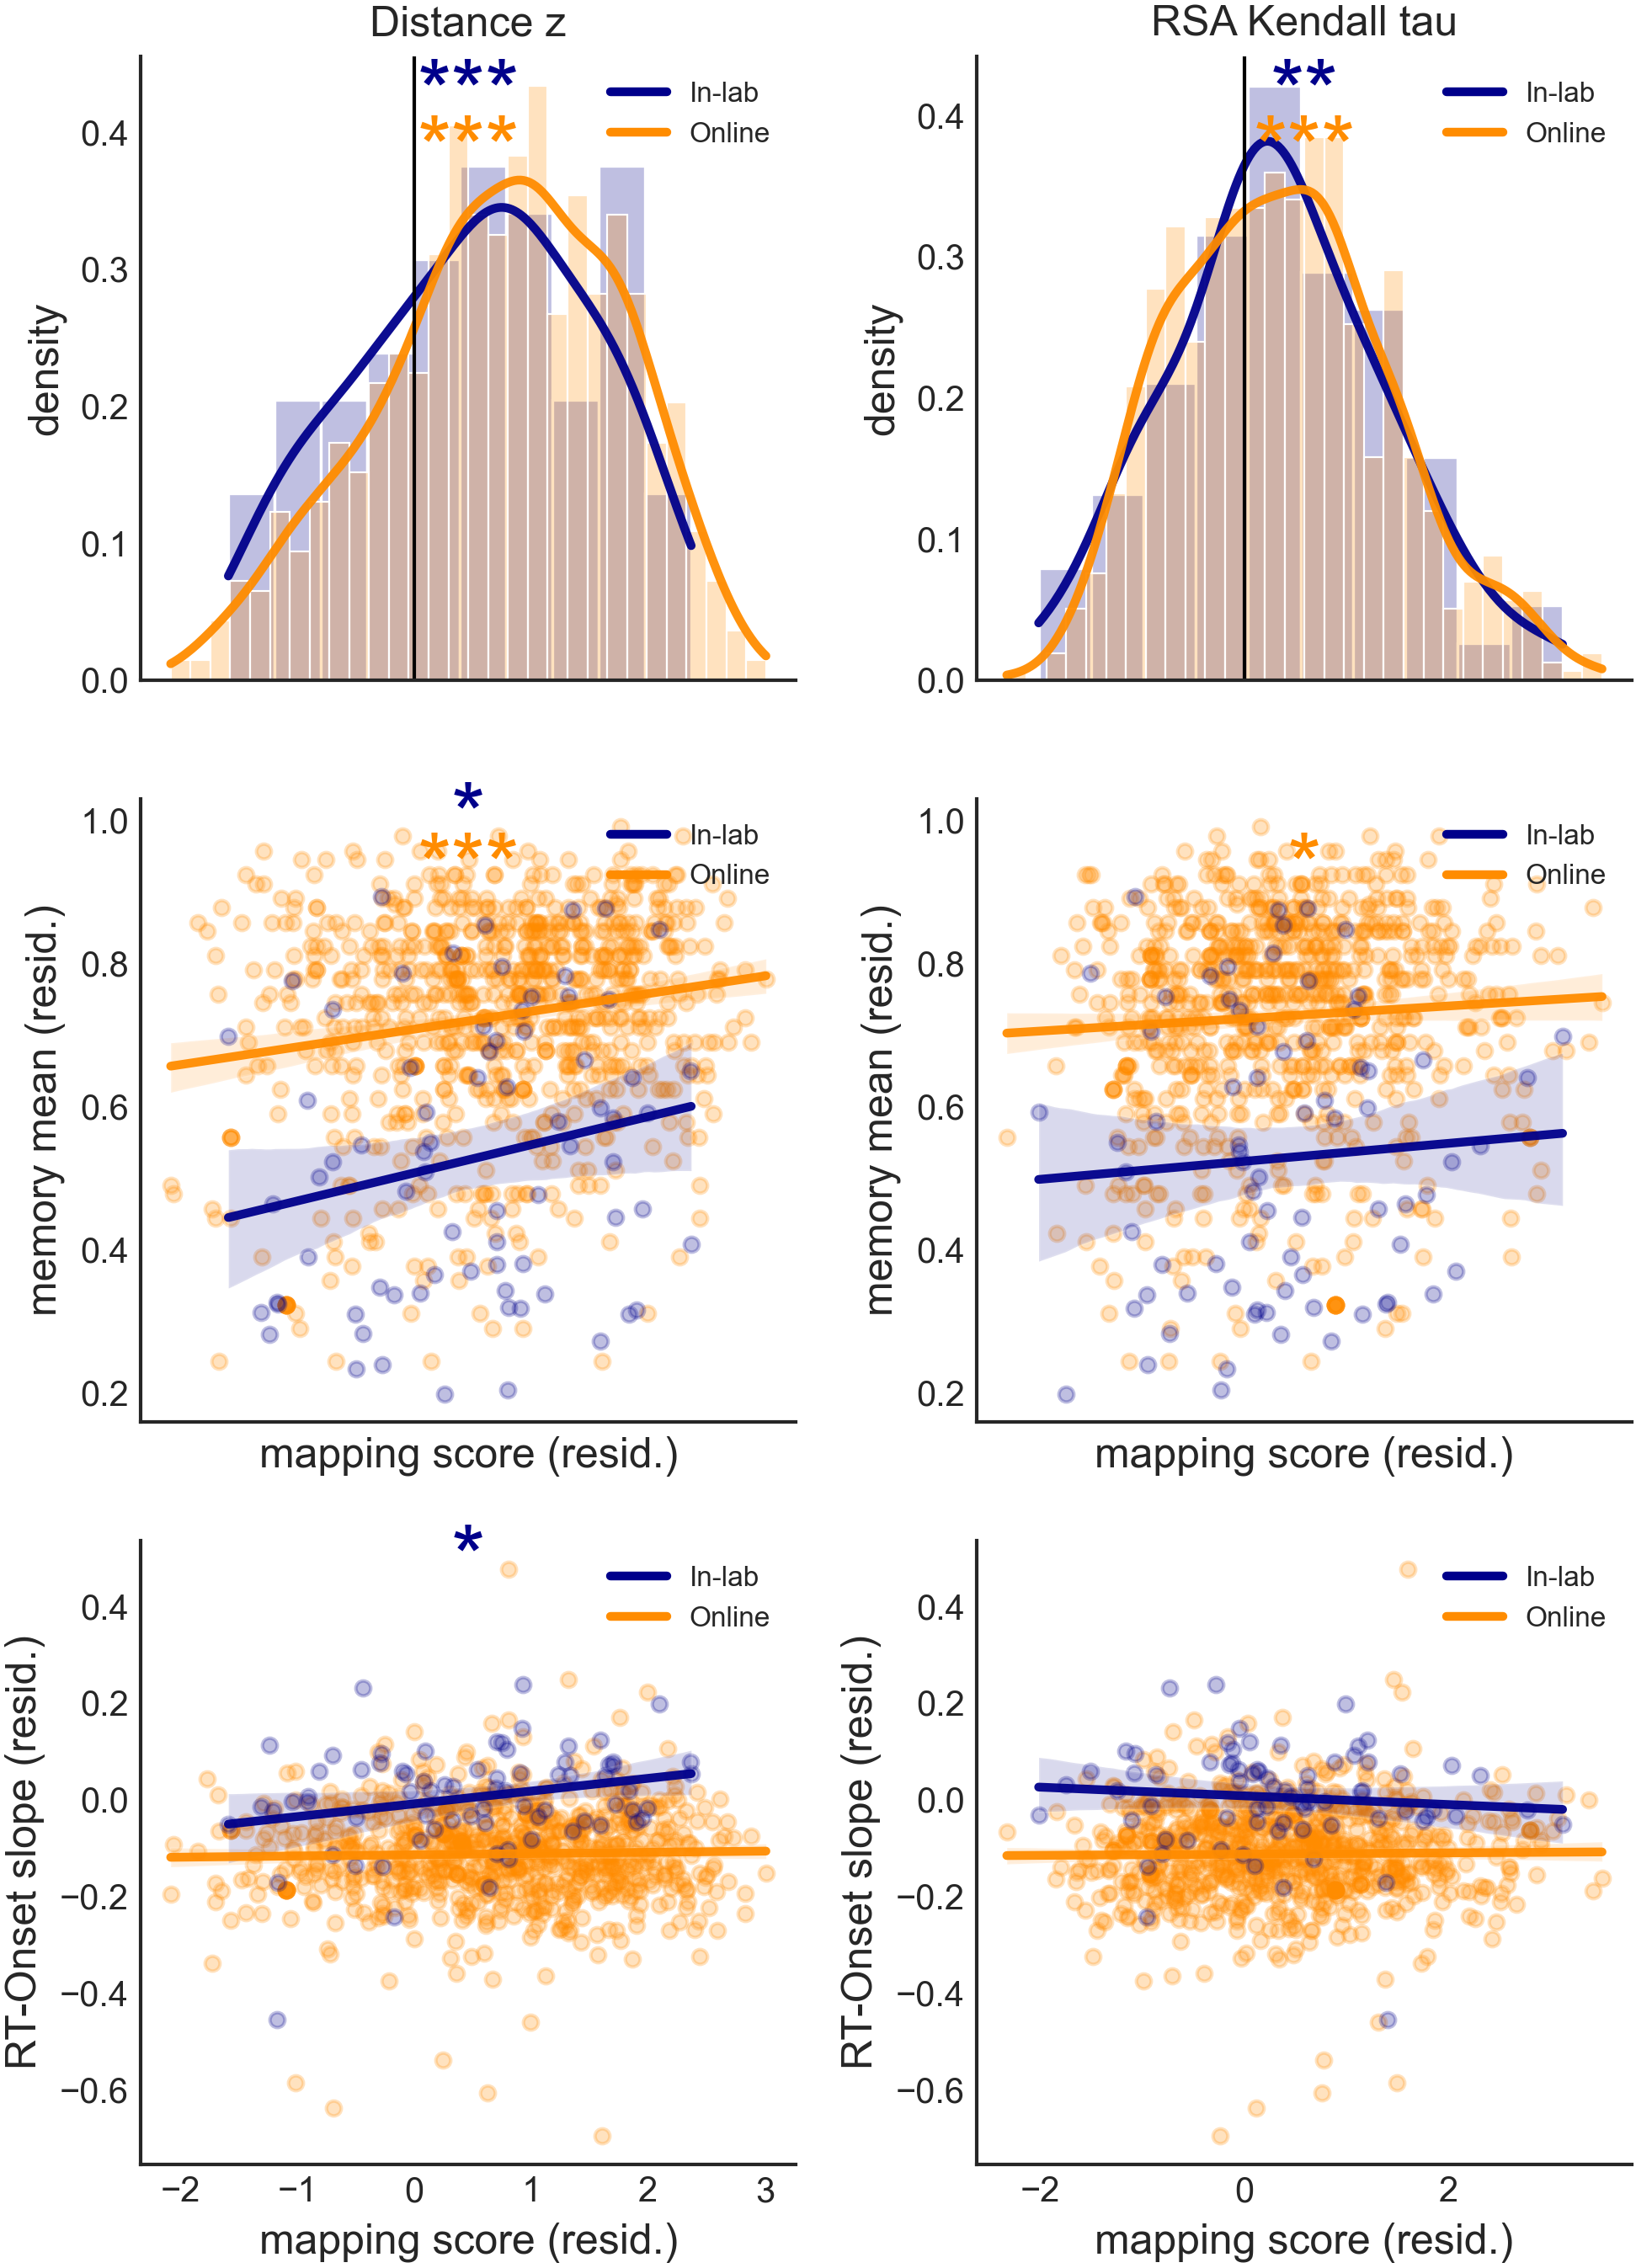

In [3]:
covariates = ['dx', 'sex', 'ctq_score']
methods    = [
    ("distance_z", "Distance z"),
    ("rsa",        "RSA Kendall tau"),
]

rng = np.random.default_rng(0)

fig, axs = plt.subplots(
    3, len(methods),
    figsize=(3.4 * len(methods), 9.3),
    sharex="col",
    sharey=False
)
axs = np.atleast_2d(axs)

for j, (method, title) in enumerate(methods):

    ax_sc   = axs[1, j]
    # ---- Row 1: Hist + KDE (in-lab vs online) + stars + legend + shared xlim
    ax = axs[0, j]
    ax, (xmin, xmax) = histplot_samples(
        data,
        data_online,
        x=f"mapping_score_{method}",
        covariates=covariates,
        ax=ax,
        bins=10,
        stat="density",
        kde=True,
        alpha=0.25,
        return_xlim=True,
    )
    ax.set_title(title)
    ax.set_xlabel("mapping score (resid.)")
    ax.set_ylabel("density")

    # ---- Row 2: mapping_score vs memory_mean (in-lab vs online) + stars + legend
    ax = axs[1, j]
    regplot_samples(
        data,
        data_online,
        x=f"mapping_score_{method}",
        y="memory_mean",
        covariates=covariates,  
        ax=ax,
        set_xlim=(xmin, xmax),
    )
    ax.set_xlabel("mapping score (resid.)")
    ax.set_ylabel("memory mean (resid.)")

    # ---- Row 3
    ax = axs[2, j]
    regplot_samples(
        data,
        data_online,
        x=f"mapping_score_{method}",
        y='beta_onset',
        covariates=covariates,
        ax=ax,
        set_xlim=None,
    )
    ax.set_xlabel("mapping score (resid.)")
    ax.set_ylabel("RT-Onset slope (resid.)")

plt.tight_layout()
save_plot(f"{results_dir}/behavior/mapping-scores_relationships.png", dpi=300)
plt.show()

## mapping-memory

<h1 align=center> is it related to semantic embeddings? </h1>

project embeddings into a learned affiliation v. power axis...

In [ ]:
subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Tavares.pkl")

sub_dict = subject_data[18001]

# CHARACTERS has the character names in order
CHARACTERS_ = CHARACTERS[:5] # only the first 5

behavior = sub_dict['behavior']
behavior_by_char = organize_by_character(behavior) # 5 x (12 x n_features)

embd_dict = sub_dict['embeddings']
choice_embds_by_char = organize_by_character(embd_dict['choice']) # 5 x (12 x n_dimensions)

dots = sub_dict['dots'] # 5 x 2


In [ ]:
sub_dict['embeddings']['choice_diff']

dict_keys(['choice', 'choice_diff', 'choice_diff_local', 'choice_diff_prev1', 'choice_diff_prev3', 'choice_diff_history', 'running_mean', 'running_variance', 'surprise'])

In [23]:
# ============================================================
# Predict post-task dot locations from behavior and embeddings
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.stats import kendalltau, wilcoxon

from sklearn.model_selection import (
    LeaveOneGroupOut,
    GroupKFold,
    GridSearchCV,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)


# ------------------------------------------------------------
# Feature helpers
# ------------------------------------------------------------

def _l2_normalize_rows(X, eps=1e-12):
    """
    L2-normalize each row of X.

    Returns
    -------
    X_normalized : array
    good_rows : boolean array
    """
    X = np.asarray(X, float)

    norms = np.linalg.norm(X, axis=1, keepdims=True)

    good = (
        np.isfinite(X).all(axis=1)
        & np.isfinite(norms[:, 0])
        & (norms[:, 0] > eps)
    )

    out = np.full_like(X, np.nan, dtype=float)
    out[good] = X[good] / norms[good]

    return out, good


def mean_embedding(E, eps=1e-12):
    """
    Compute a character-level semantic centroid from trial embeddings.

    Procedure:
      1. normalize each trial embedding
      2. average across the character's trials
      3. normalize the resulting centroid
    """
    E = np.asarray(E, float)

    U, good = _l2_normalize_rows(E, eps=eps)

    if good.sum() == 0:
        raise ValueError("No finite, non-zero embeddings.")

    centroid = np.mean(U[good], axis=0)
    norm = np.linalg.norm(centroid)

    if not np.isfinite(norm) or norm <= eps:
        raise ValueError("Mean embedding has zero or invalid norm.")

    return centroid / norm


# ------------------------------------------------------------
# Construct participant × character dataset
# ------------------------------------------------------------

def build_dots_prediction_dataset(
    subject_data,
    *,
    character_names,
    embedding_key="choice",
    expected_trials_per_character=12,
    require_complete_subject=True,
):
    """
    Create one observation per participant × character.

    Predictors
    ----------
    role:
        One-hot character role. Controls for generic character/narrative effects.

    behavior_final:
        Final affiliation and power coordinates.

    behavior_full:
        Final affiliation/power coordinates plus the complete signed choice
        sequence for that character.

    embedding_mean:
        Mean normalized embedding across the character's chosen options.

    Outcome
    -------
    dots:
        Post-task affiliation and power location.

    Assumptions
    -----------
    - embeddings are trial-aligned with behavior
    - character roles are coded 1...len(character_names)
    - dots[:, 0] = affiliation
    - dots[:, 1] = power
    """
    character_names = list(character_names)
    n_characters = len(character_names)

    meta_rows = []
    role_rows = []
    behavior_final_rows = []
    behavior_full_rows = []
    embedding_mean_rows = []
    target_rows = []

    skipped = {}

    for sub_id, sub_dict in subject_data.items():

        try:
            behavior = (
                sub_dict["behavior"]
                .copy()
                .reset_index(drop=True)
            )

            embeddings = np.asarray(
                sub_dict["embeddings"][embedding_key],
                float,
            )

            dots = np.asarray(
                sub_dict["dots"],
                float,
            ).squeeze()

            # -------------------------
            # Basic checks
            # -------------------------

            if embeddings.ndim != 2:
                raise ValueError(
                    f"Embeddings must be trials × dimensions; "
                    f"got {embeddings.shape}."
                )

            if len(behavior) != embeddings.shape[0]:
                raise ValueError(
                    "Behavior/embedding length mismatch: "
                    f"{len(behavior)} vs {embeddings.shape[0]}."
                )

            if dots.ndim != 2 or dots.shape[1] != 2:
                raise ValueError(
                    f"Dots must be characters × 2; got {dots.shape}."
                )

            role_col = next(
                (
                    col
                    for col in [
                        "character_role_num",
                        "char_role_num",
                    ]
                    if col in behavior.columns
                ),
                None,
            )

            if role_col is None:
                raise KeyError(
                    "Behavior has no character role column."
                )

            sort_col = next(
                (
                    col
                    for col in [
                        "character_decision_num",
                        "onset",
                        "decision_num",
                        "trial_num",
                    ]
                    if col in behavior.columns
                ),
                None,
            )

            decision_cols = [
                "affil_decision",
                "power_decision",
            ]

            if not set(decision_cols).issubset(behavior.columns):
                raise KeyError(
                    "Behavior must contain affil_decision "
                    "and power_decision."
                )

            # Optional explicit dot-role ordering
            dots_roles = sub_dict.get("dots_roles", None)

            if dots_roles is not None:
                dots_roles = [
                    str(role)
                    for role in list(dots_roles)
                ]

            subject_rows = []

            # -------------------------
            # One row per character
            # -------------------------

            for role_num, character in enumerate(
                character_names,
                start=1,
            ):
                role_values = pd.to_numeric(
                    behavior[role_col],
                    errors="coerce",
                ).to_numpy(float)

                trial_idx = np.flatnonzero(
                    role_values == role_num
                )

                if trial_idx.size == 0:
                    raise ValueError(
                        f"No trials for role {role_num}: {character}."
                    )

                # Preserve within-character temporal order
                if sort_col is not None:
                    sort_values = pd.to_numeric(
                        behavior.iloc[trial_idx][sort_col],
                        errors="coerce",
                    ).to_numpy(float)

                    if not np.isfinite(sort_values).all():
                        raise ValueError(
                            f"Non-finite {sort_col} for {character}."
                        )

                    trial_idx = trial_idx[
                        np.argsort(sort_values, kind="stable")
                    ]

                if (
                    expected_trials_per_character is not None
                    and trial_idx.size
                    != expected_trials_per_character
                ):
                    raise ValueError(
                        f"{character}: expected "
                        f"{expected_trials_per_character} trials, "
                        f"found {trial_idx.size}."
                    )

                behavior_char = behavior.iloc[trial_idx]

                choices = (
                    behavior_char[decision_cols]
                    .apply(pd.to_numeric, errors="coerce")
                    .to_numpy(float)
                )

                if not np.isfinite(choices).all():
                    raise ValueError(
                        f"Non-finite choice values for {character}."
                    )

                # Use raw task coordinates only.
                # Never use coordinates transformed using dots.
                if {
                    "affil_coord",
                    "power_coord",
                }.issubset(behavior_char.columns):

                    states = (
                        behavior_char[
                            ["affil_coord", "power_coord"]
                        ]
                        .apply(pd.to_numeric, errors="coerce")
                        .to_numpy(float)
                    )

                    if not np.isfinite(states).all():
                        states = np.cumsum(choices, axis=0)

                else:
                    states = np.cumsum(choices, axis=0)

                behavior_final = states[-1]

                # Strong behavior baseline:
                # final location + the complete 12-choice trajectory
                behavior_full = np.concatenate(
                    [
                        behavior_final,
                        choices.ravel(),
                    ]
                )

                embedding_summary = mean_embedding(
                    embeddings[trial_idx]
                )

                # Align dots to the character
                if (
                    dots_roles is not None
                    and character in dots_roles
                ):
                    dot_idx = dots_roles.index(character)
                else:
                    # Default: dots are already in character order
                    dot_idx = role_num - 1

                if dot_idx >= dots.shape[0]:
                    raise IndexError(
                        f"Dot index {dot_idx} unavailable for "
                        f"dots shape {dots.shape}."
                    )

                target = dots[dot_idx]

                if not np.isfinite(target).all():
                    raise ValueError(
                        f"Non-finite dot location for {character}."
                    )

                role_onehot = np.eye(
                    n_characters,
                    dtype=float,
                )[role_num - 1]

                subject_rows.append(
                    {
                        "meta": {
                            "sub_id": sub_id,
                            "character": character,
                            "role_num": role_num,
                        },
                        "role": role_onehot,
                        "behavior_final": behavior_final,
                        "behavior_full": behavior_full,
                        "embedding_mean": embedding_summary,
                        "target": target,
                    }
                )

            if (
                require_complete_subject
                and len(subject_rows) != n_characters
            ):
                raise ValueError(
                    f"Only {len(subject_rows)} of "
                    f"{n_characters} characters available."
                )

            # Add subject only after all characters pass
            for row in subject_rows:
                meta_rows.append(row["meta"])
                role_rows.append(row["role"])
                behavior_final_rows.append(
                    row["behavior_final"]
                )
                behavior_full_rows.append(
                    row["behavior_full"]
                )
                embedding_mean_rows.append(
                    row["embedding_mean"]
                )
                target_rows.append(row["target"])

        except Exception as exc:
            skipped[sub_id] = str(exc)

    if len(meta_rows) == 0:
        raise RuntimeError(
            "No usable participants. "
            f"First exclusions: {list(skipped.items())[:5]}"
        )

    meta = pd.DataFrame(meta_rows)

    role = np.vstack(role_rows)
    behavior_final = np.vstack(behavior_final_rows)
    behavior_full = np.vstack(behavior_full_rows)
    embedding_mean_array = np.vstack(embedding_mean_rows)
    y = np.vstack(target_rows)

    # Character role is included in every substantive model.
    # This controls for generic character and narrative structure.
    X_sets = {
        "role_only": role,

        "behavior_final": np.column_stack(
            [role, behavior_final]
        ),

        "behavior_full": np.column_stack(
            [role, behavior_full]
        ),

        "embedding_mean": np.column_stack(
            [role, embedding_mean_array]
        ),

        "behavior_full+embedding": np.column_stack(
            [
                role,
                behavior_full,
                embedding_mean_array,
            ]
        ),
    }

    return {
        "meta": meta,
        "groups": meta["sub_id"].to_numpy(),
        "y": y,
        "X": X_sets,
        "raw": {
            "role": role,
            "behavior_final": behavior_final,
            "behavior_full": behavior_full,
            "embedding_mean": embedding_mean_array,
        },
        "skipped": skipped,
    }


# ------------------------------------------------------------
# Nested leave-one-participant-out prediction
# ------------------------------------------------------------

def nested_loso_ridge_predict(
    dataset,
    *,
    alpha_grid=None,
    inner_splits=5,
    n_jobs=-1,
):
    """
    Nested leave-one-subject-out prediction.

    Outer loop:
        holds out one complete participant.

    Inner loop:
        selects the Ridge regularization parameter using grouped CV.

    Targets are standardized using training data only, then transformed
    back into the original dot-coordinate units.
    """
    if alpha_grid is None:
        alpha_grid = np.logspace(-4, 6, 21)

    y = np.asarray(dataset["y"], float)
    groups = np.asarray(dataset["groups"])
    meta = dataset["meta"].reset_index(drop=True)

    outer_cv = LeaveOneGroupOut()

    prediction_frames = []
    tuning_rows = []

    for model_name, X in dataset["X"].items():

        X = np.asarray(X, float)

        predictions = np.full_like(
            y,
            np.nan,
            dtype=float,
        )

        for train_idx, test_idx in outer_cv.split(
            X,
            y,
            groups,
        ):
            X_train = X[train_idx]
            X_test = X[test_idx]

            y_train = y[train_idx]
            train_groups = groups[train_idx]

            # Standardize Y using training data only
            y_mean = y_train.mean(axis=0)
            y_sd = y_train.std(axis=0, ddof=1)

            y_sd[
                ~np.isfinite(y_sd)
                | (y_sd < 1e-12)
            ] = 1.0

            y_train_z = (
                y_train - y_mean
            ) / y_sd

            n_train_groups = np.unique(
                train_groups
            ).size

            n_inner_splits = min(
                inner_splits,
                n_train_groups,
            )

            if n_inner_splits < 2:
                raise ValueError(
                    "Need at least two training participants "
                    "for inner cross-validation."
                )

            pipeline = make_pipeline(
                StandardScaler(),
                Ridge(solver="lsqr"),
            )

            search = GridSearchCV(
                estimator=pipeline,
                param_grid={
                    "ridge__alpha": alpha_grid
                },
                scoring="neg_mean_squared_error",
                cv=GroupKFold(
                    n_splits=n_inner_splits
                ),
                n_jobs=n_jobs,
                refit=True,
            )

            search.fit(
                X_train,
                y_train_z,
                groups=train_groups,
            )

            predicted_z = search.predict(X_test)

            predictions[test_idx] = (
                predicted_z * y_sd
                + y_mean
            )

            tuning_rows.append(
                {
                    "model": model_name,
                    "held_out_sub_id": groups[test_idx][0],
                    "best_alpha": (
                        search.best_params_[
                            "ridge__alpha"
                        ]
                    ),
                    "inner_cv_mse_z": -search.best_score_,
                }
            )

        if not np.isfinite(predictions).all():
            raise RuntimeError(
                f"Missing outer-CV predictions for {model_name}."
            )

        model_predictions = meta.copy()

        model_predictions["true_affiliation"] = y[:, 0]
        model_predictions["true_power"] = y[:, 1]

        model_predictions["pred_affiliation"] = (
            predictions[:, 0]
        )
        model_predictions["pred_power"] = (
            predictions[:, 1]
        )

        model_predictions["model"] = model_name

        prediction_frames.append(model_predictions)

    predictions_df = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    tuning_df = pd.DataFrame(tuning_rows)

    return predictions_df, tuning_df


# ------------------------------------------------------------
# Evaluate held-out predictions
# ------------------------------------------------------------

def evaluate_dots_predictions(predictions_df):
    """
    Evaluate both:

    1. absolute coordinate prediction
       - RMSE
       - MAE
       - R²

    2. within-participant relational geometry
       - Kendall tau between predicted and observed
         pairwise character distances
    """
    subject_rows = []
    summary_rows = []

    for model, model_df in predictions_df.groupby(
        "model",
        sort=False,
    ):
        y_true = model_df[
            ["true_affiliation", "true_power"]
        ].to_numpy(float)

        y_pred = model_df[
            ["pred_affiliation", "pred_power"]
        ].to_numpy(float)

        r2_axes = r2_score(
            y_true,
            y_pred,
            multioutput="raw_values",
        )

        summary = {
            "model": model,
            "rmse": float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        y_pred,
                    )
                )
            ),
            "mae": float(
                mean_absolute_error(
                    y_true,
                    y_pred,
                )
            ),
            "r2_affiliation": float(r2_axes[0]),
            "r2_power": float(r2_axes[1]),
            "r2_mean": float(np.mean(r2_axes)),
        }

        geometry_taus = []

        for sub_id, sub_df in model_df.groupby(
            "sub_id",
            sort=False,
        ):
            y_true_sub = sub_df[
                ["true_affiliation", "true_power"]
            ].to_numpy(float)

            y_pred_sub = sub_df[
                ["pred_affiliation", "pred_power"]
            ].to_numpy(float)

            rmse_sub = float(
                np.sqrt(
                    mean_squared_error(
                        y_true_sub,
                        y_pred_sub,
                    )
                )
            )

            mae_sub = float(
                mean_absolute_error(
                    y_true_sub,
                    y_pred_sub,
                )
            )

            observed_distances = pdist(
                y_true_sub,
                metric="euclidean",
            )

            predicted_distances = pdist(
                y_pred_sub,
                metric="euclidean",
            )

            tau = kendalltau(
                observed_distances,
                predicted_distances,
            ).statistic

            subject_rows.append(
                {
                    "sub_id": sub_id,
                    "model": model,
                    "rmse": rmse_sub,
                    "mae": mae_sub,
                    "geometry_tau": (
                        float(tau)
                        if np.isfinite(tau)
                        else np.nan
                    ),
                }
            )

            if np.isfinite(tau):
                geometry_taus.append(float(tau))

        summary["mean_geometry_tau"] = (
            float(np.mean(geometry_taus))
            if geometry_taus
            else np.nan
        )

        summary_rows.append(summary)

    summary_df = pd.DataFrame(summary_rows)
    subject_scores_df = pd.DataFrame(subject_rows)

    return summary_df, subject_scores_df


# ------------------------------------------------------------
# Paired participant-level model comparisons
# ------------------------------------------------------------

def paired_model_tests(
    subject_scores_df,
    *,
    reference="behavior_full",
    candidates=None,
    alternative="directional",
):
    """
    Compare each candidate against the behavior-only reference model.

    For RMSE:
        candidate < reference is better.

    For geometry_tau:
        candidate > reference is better.

    Set alternative="two-sided" for fully exploratory analyses.
    """
    if candidates is None:
        candidates = [
            "embedding_mean",
            "behavior_full+embedding",
        ]

    rows = []

    for candidate in candidates:

        for metric in ["rmse", "geometry_tau"]:

            wide = subject_scores_df.pivot(
                index="sub_id",
                columns="model",
                values=metric,
            )

            if (
                reference not in wide.columns
                or candidate not in wide.columns
            ):
                continue

            paired = wide[
                [reference, candidate]
            ].dropna()

            if len(paired) < 3:
                continue

            if alternative == "two-sided":
                test_alternative = "two-sided"

            elif metric == "rmse":
                # Candidate expected to have lower error
                test_alternative = "less"

            else:
                # Candidate expected to have higher tau
                test_alternative = "greater"

            try:
                statistic, p_value = wilcoxon(
                    paired[candidate],
                    paired[reference],
                    alternative=test_alternative,
                )
            except ValueError:
                statistic = np.nan
                p_value = np.nan

            rows.append(
                {
                    "candidate": candidate,
                    "reference": reference,
                    "metric": metric,
                    "n_subjects": len(paired),
                    "candidate_mean": (
                        paired[candidate].mean()
                    ),
                    "reference_mean": (
                        paired[reference].mean()
                    ),
                    "candidate_minus_reference": (
                        paired[candidate]
                        - paired[reference]
                    ).mean(),
                    "wilcoxon_stat": statistic,
                    "p_value": p_value,
                    "alternative": test_alternative,
                }
            )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Plot participant-level model performance
# ------------------------------------------------------------

def plot_dots_model_comparison(
    subject_scores_df,
    *,
    order=None,
):
    if order is None:
        order = [
            "role_only",
            "behavior_final",
            "behavior_full",
            "embedding_mean",
            "behavior_full+embedding",
        ]

    order = [
        model
        for model in order
        if model
        in subject_scores_df["model"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 4.5),
    )

    # -------------------------
    # Coordinate prediction
    # -------------------------

    sns.barplot(
        data=subject_scores_df,
        x="model",
        y="rmse",
        order=order,
        errorbar=("ci", 68),
        color="0.65",
        alpha=0.75,
        ax=axes[0],
    )

    sns.stripplot(
        data=subject_scores_df,
        x="model",
        y="rmse",
        order=order,
        color="0.2",
        jitter=0.12,
        alpha=0.6,
        ax=axes[0],
    )

    axes[0].set_title(
        "Held-out dot-coordinate error"
    )
    axes[0].set_ylabel(
        "RMSE (lower is better)"
    )
    axes[0].set_xlabel("")

    # -------------------------
    # Character geometry
    # -------------------------

    sns.barplot(
        data=subject_scores_df,
        x="model",
        y="geometry_tau",
        order=order,
        errorbar=("ci", 68),
        color="0.65",
        alpha=0.75,
        ax=axes[1],
    )

    sns.stripplot(
        data=subject_scores_df,
        x="model",
        y="geometry_tau",
        order=order,
        color="0.2",
        jitter=0.12,
        alpha=0.6,
        ax=axes[1],
    )

    axes[1].axhline(
        0,
        color="black",
        linewidth=0.8,
    )

    axes[1].set_title(
        "Held-out character geometry"
    )
    axes[1].set_ylabel(
        "Kendall tau (higher is better)"
    )
    axes[1].set_xlabel("")

    for ax in axes:
        ax.tick_params(
            axis="x",
            rotation=40,
        )

        for label in ax.get_xticklabels():
            label.set_ha("right")

    plt.tight_layout()

    return fig, axes


# ------------------------------------------------------------
# Plot observed versus predicted positions for one held-out
# participant
# ------------------------------------------------------------

def plot_held_out_subject(
    predictions_df,
    sub_id,
    *,
    models=None,
):
    if models is None:
        models = [
            "behavior_full",
            "embedding_mean",
            "behavior_full+embedding",
        ]

    models = [
        model
        for model in models
        if model in predictions_df["model"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(5 * len(models), 4.5),
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, model in zip(axes, models):

        sub_df = predictions_df[
            (predictions_df["sub_id"] == sub_id)
            & (predictions_df["model"] == model)
        ].copy()

        if sub_df.empty:
            ax.set_axis_off()
            continue

        ax.scatter(
            sub_df["true_affiliation"],
            sub_df["true_power"],
            s=70,
            label="Observed",
        )

        ax.scatter(
            sub_df["pred_affiliation"],
            sub_df["pred_power"],
            s=70,
            marker="x",
            label="Predicted",
        )

        for row in sub_df.itertuples(index=False):

            ax.plot(
                [
                    row.true_affiliation,
                    row.pred_affiliation,
                ],
                [
                    row.true_power,
                    row.pred_power,
                ],
                linewidth=0.8,
                alpha=0.5,
            )

            ax.text(
                row.true_affiliation,
                row.true_power,
                str(row.character),
                fontsize=8,
            )

        ax.set_title(model)
        ax.set_xlabel("Affiliation")
        ax.set_ylabel("Power")

        ax.set_aspect(
            "equal",
            adjustable="datalim",
        )

        ax.legend(frameon=False)

    fig.suptitle(
        f"Held-out predictions: participant {sub_id}"
    )

    plt.tight_layout()

    return fig, axes

Included participants: 66
Participant-character observations: 330
Skipped participants: 1
[(23007, 'Non-finite dot location for first.')]


,model,rmse,mae,r2_affiliation,r2_power,r2_mean,mean_geometry_tau
0,role_only,0.449543,0.358383,0.012917,0.478644,0.245780,0.316498
1,behavior_final,0.452303,0.361055,0.001374,0.471132,0.236253,0.303030
3,embedding_mean,0.453387,0.363266,0.004119,0.455140,0.229629,0.320539
4,behavior_full+embedding,0.453550,0.363421,0.003397,0.454761,0.229079,0.322559
2,behavior_full,0.465099,0.374911,-0.047305,0.425393,0.189044,0.255892


,candidate,reference,metric,n_subjects,candidate_mean,reference_mean,candidate_minus_reference,wilcoxon_stat,p_value,alternative
0,embedding_mean,behavior_full,rmse,66,0.436968,0.449812,-0.012844,650.0,0.001808,less
1,embedding_mean,behavior_full,geometry_tau,66,0.320539,0.255892,0.064646,1187.5,0.000737,greater
2,behavior_full+embedding,behavior_full,rmse,66,0.437143,0.449812,-0.012669,637.0,0.001382,less
3,behavior_full+embedding,behavior_full,geometry_tau,66,0.322559,0.255892,0.066667,1157.5,0.000579,greater


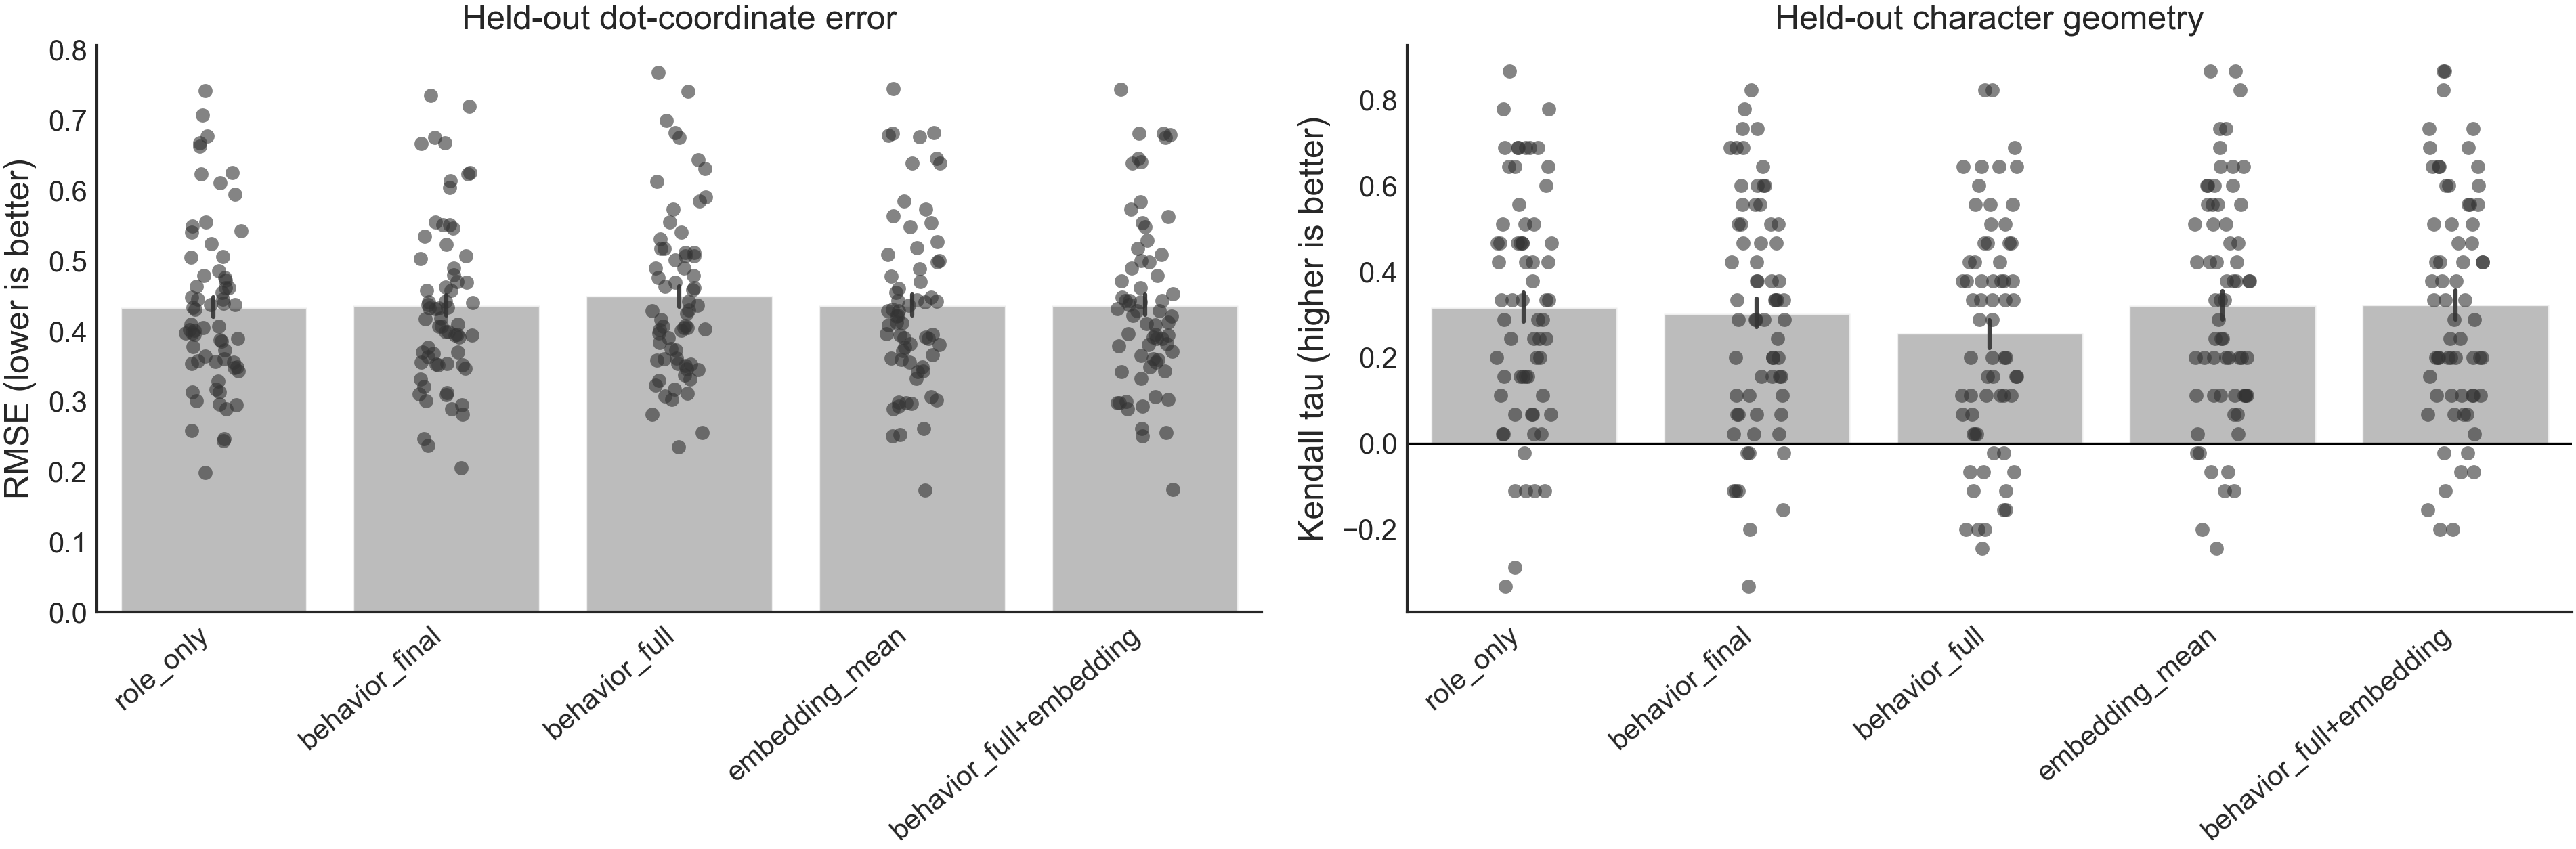

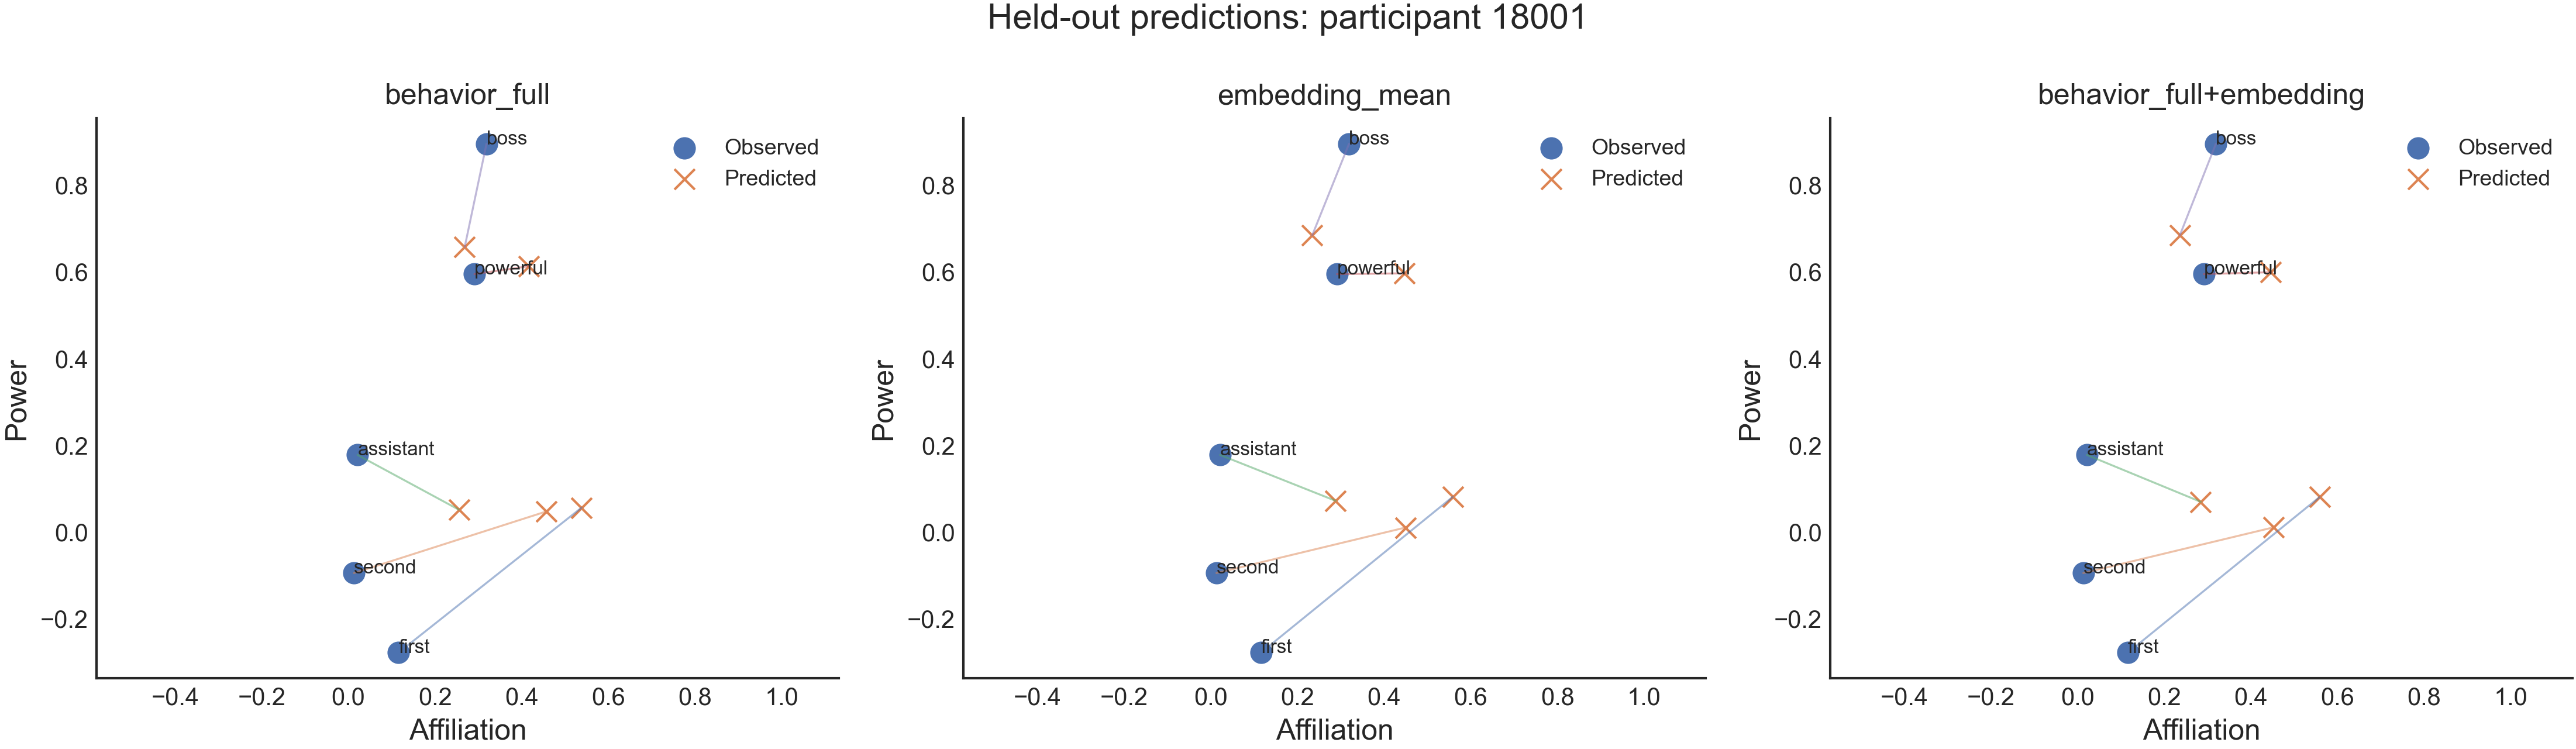

In [24]:
subject_data = load_pickle(
    "../../../analyses/lss_decision/subject_data_Tavares.pkl"
)

CHARACTERS_ = CHARACTERS[:5]

dataset = build_dots_prediction_dataset(
    subject_data,
    character_names=CHARACTERS_,
    embedding_key="choice",
    expected_trials_per_character=12,
)

print(
    "Included participants:",
    dataset["meta"]["sub_id"].nunique(),
)

print(
    "Participant-character observations:",
    len(dataset["meta"]),
)

print(
    "Skipped participants:",
    len(dataset["skipped"]),
)

if dataset["skipped"]:
    print(
        list(dataset["skipped"].items())[:10]
    )


predictions, tuning = nested_loso_ridge_predict(
    dataset,
    inner_splits=5,
    n_jobs=-1,
)

summary, subject_scores = evaluate_dots_predictions(
    predictions
)

display(
    summary.sort_values("rmse")
)

tests = paired_model_tests(
    subject_scores,
    reference="behavior_full",
    candidates=[
        "embedding_mean",
        "behavior_full+embedding",
    ],
    # Use "two-sided" if this is exploratory.
    alternative="directional",
)

display(tests)

plot_dots_model_comparison(subject_scores)
plt.show()

plot_held_out_subject(
    predictions,
    sub_id=18001,
)
plt.show()

Included participants: 66
Included participant-character rows: 330
Skipped participants: 1
[(23007, 'Invalid dot position for first.')]
Outer fold   1/66: held out 18001
Outer fold   2/66: held out 18002
Outer fold   3/66: held out 18003
Outer fold   4/66: held out 18004
Outer fold   5/66: held out 18005
Outer fold   6/66: held out 18006
Outer fold   7/66: held out 18007
Outer fold   8/66: held out 18009
Outer fold   9/66: held out 18010
Outer fold  10/66: held out 18011
Outer fold  11/66: held out 18013
Outer fold  12/66: held out 18015
Outer fold  13/66: held out 18017
Outer fold  14/66: held out 18018
Outer fold  15/66: held out 19003
Outer fold  16/66: held out 19004
Outer fold  17/66: held out 19005
Outer fold  18/66: held out 19007
Outer fold  19/66: held out 19008
Outer fold  20/66: held out 19009
Outer fold  21/66: held out 19014
Outer fold  22/66: held out 19020
Outer fold  23/66: held out 19027
Outer fold  24/66: held out 19028
Outer fold  25/66: held out 19031
Outer fold  26

,model,rmse,mae,residual_r2_affiliation,residual_r2_power,residual_r2_mean,mean_geometry_tau
0,character_mean,0.449579,0.357763,0.000000,0.000000,0.000000,0.316498
1,behavior_endpoint,0.449757,0.357931,-0.000745,-0.000958,-0.000851,0.315152
2,behavior_full,0.449931,0.358012,-0.001966,-0.000233,-0.001100,0.312458
4,behavior_full+choice_diff,0.450134,0.358111,-0.002711,-0.001661,-0.002186,0.313131
3,choice_diff_mean,0.450513,0.358525,-0.004332,-0.003585,-0.003958,0.313131


,candidate,reference,metric,n,candidate_mean,reference_mean,candidate_minus_reference,wilcoxon_stat,p_value,alternative
0,choice_diff_mean,behavior_full,rmse,66,0.434572,0.434176,0.000396,1169.0,0.657498,candidate < reference
1,choice_diff_mean,behavior_full,geometry_tau,66,0.313131,0.312458,0.000673,77.0,0.490516,candidate > reference
2,behavior_full+choice_diff,behavior_full,rmse,66,0.434299,0.434176,0.000122,1036.0,0.328532,candidate < reference
3,behavior_full+choice_diff,behavior_full,geometry_tau,66,0.313131,0.312458,0.000673,9.5,0.293968,candidate > reference
4,choice_diff_mean,character_mean,rmse,66,0.434572,0.433816,0.000756,1172.0,0.664511,candidate < reference
5,choice_diff_mean,character_mean,geometry_tau,66,0.313131,0.316498,-0.003367,40.0,0.872775,candidate > reference


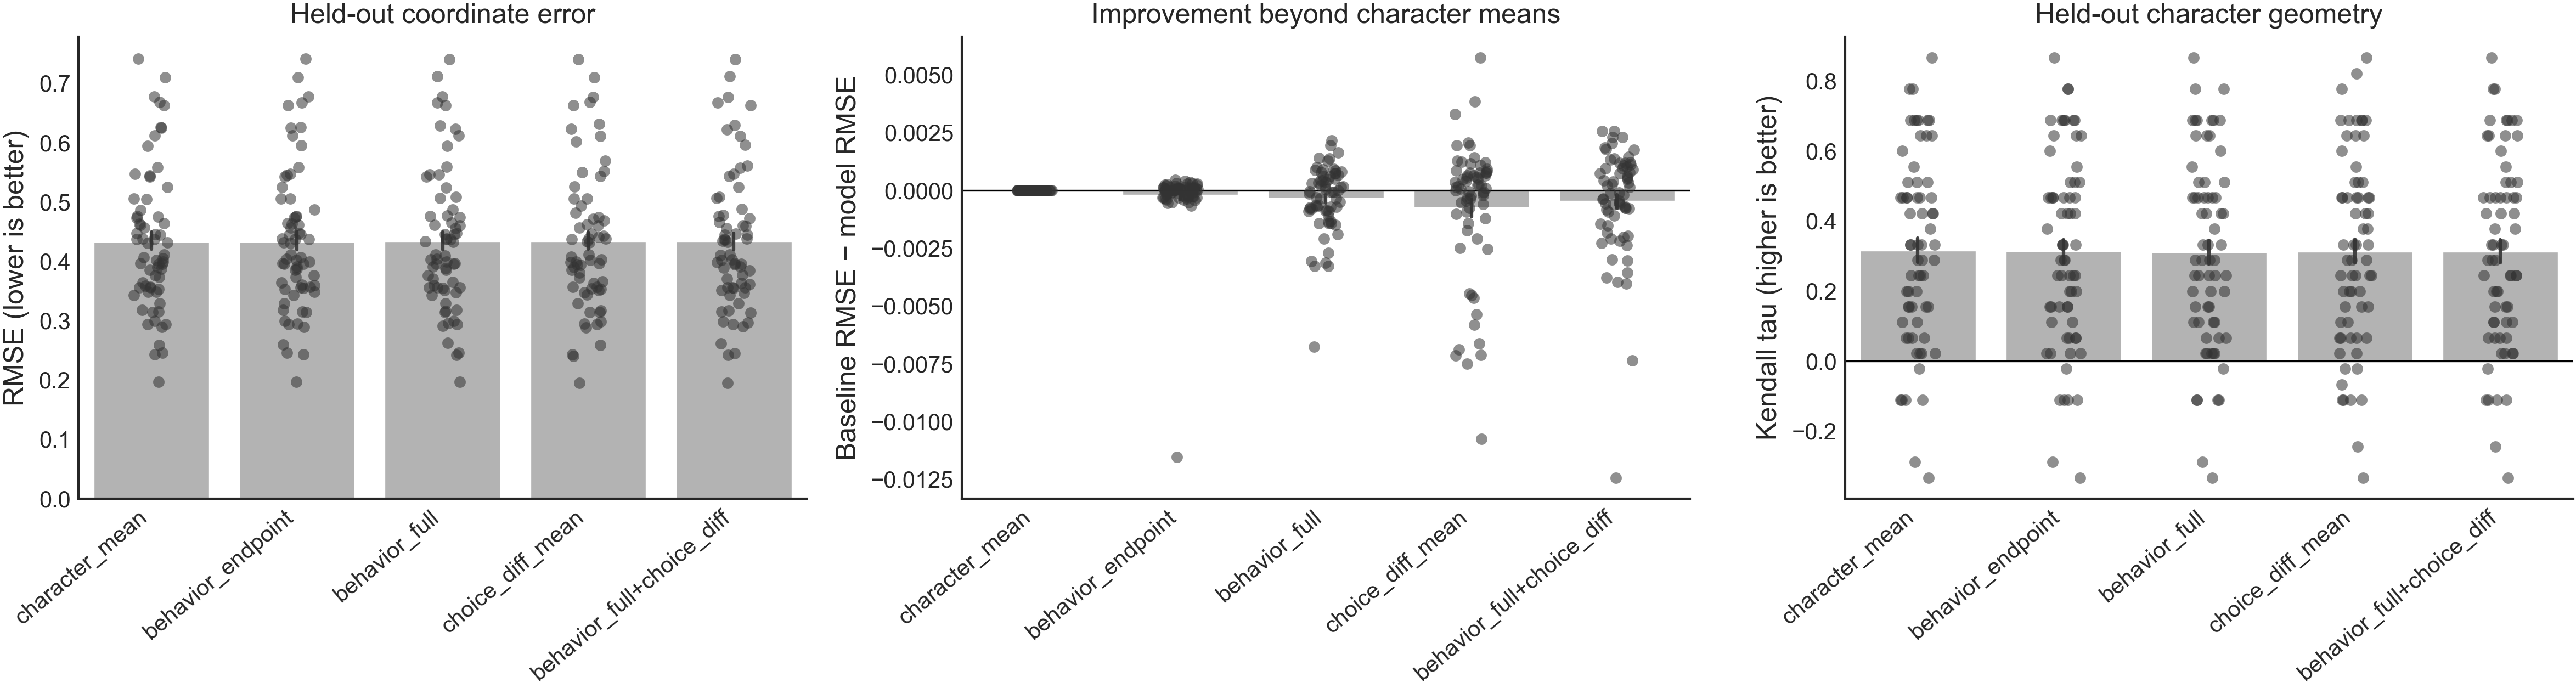

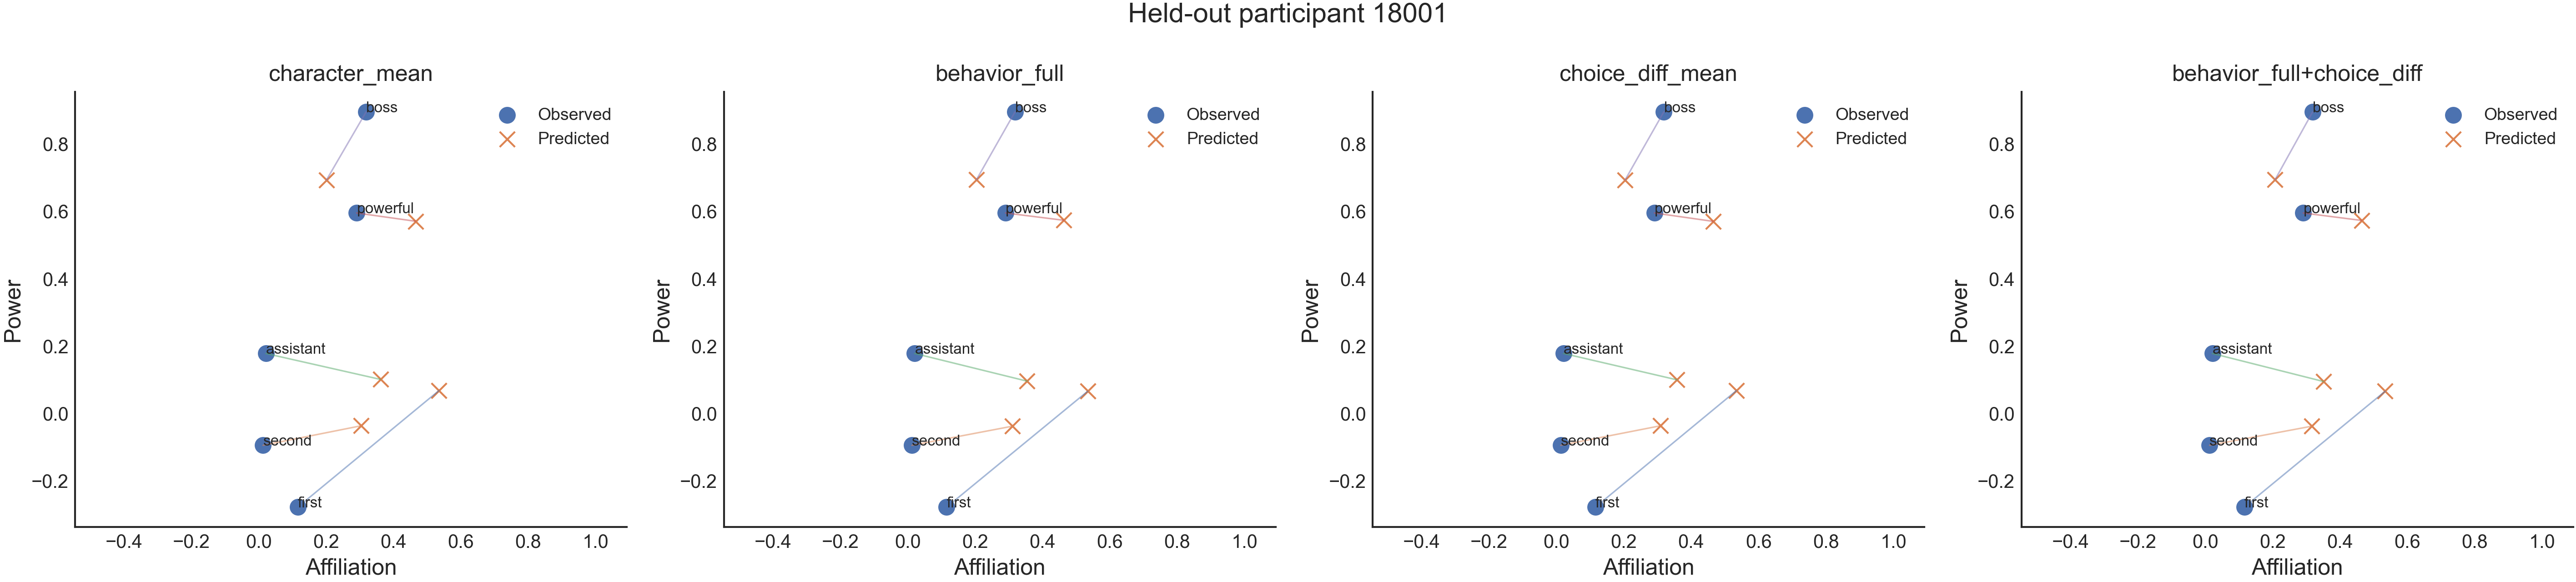

In [27]:
# ============================================================
# Character-residualized prediction of post-task dot locations
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.stats import kendalltau, wilcoxon

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 1. Build participant × character dataset
# ------------------------------------------------------------

def build_character_dots_dataset(
    subject_data,
    *,
    character_names,
    embedding_key="choice_diff",
    expected_trials_per_character=12,
):
    """
    Create one observation per participant × character.

    Feature blocks
    --------------
    behavior_endpoint:
        Final affiliation/power coordinates.

    behavior_full:
        Final affiliation/power coordinates plus the full signed
        affiliation/power choice sequence.

    choice_diff_mean:
        Mean chosen-minus-unchosen embedding across the character's
        interactions. Because every character has the same number of
        interactions, mean and cumulative sum differ only by scale.

    Outcome
    -------
    dots:
        Participant's post-task affiliation/power placement.

    Important
    ---------
    This assumes:
        embeddings["choice_diff"][t]
    is consistently defined as chosen minus unchosen, or consistently
    in the reverse direction. It should not merely be option 1 minus
    option 2 regardless of the participant's choice.
    """
    character_names = list(character_names)

    meta_rows = []
    target_rows = []

    behavior_endpoint_rows = []
    behavior_full_rows = []
    choice_diff_mean_rows = []

    skipped = {}

    for sub_id, sub_dict in subject_data.items():

        try:
            behavior = (
                sub_dict["behavior"]
                .copy()
                .reset_index(drop=True)
            )

            choice_diff = np.asarray(
                sub_dict["embeddings"][embedding_key],
                dtype=float,
            )

            dots = np.asarray(
                sub_dict["dots"],
                dtype=float,
            ).squeeze()

            # -------------------------
            # Basic validation
            # -------------------------

            if choice_diff.ndim != 2:
                raise ValueError(
                    f"{embedding_key} must be trials × embedding dimensions; "
                    f"got {choice_diff.shape}."
                )

            if len(behavior) != choice_diff.shape[0]:
                raise ValueError(
                    "Behavior and embeddings have different trial counts: "
                    f"{len(behavior)} versus {choice_diff.shape[0]}."
                )

            if dots.ndim != 2 or dots.shape[1] != 2:
                raise ValueError(
                    f"dots must be characters × 2; got {dots.shape}."
                )

            role_col = next(
                (
                    col
                    for col in [
                        "character_role_num",
                        "char_role_num",
                    ]
                    if col in behavior.columns
                ),
                None,
            )

            if role_col is None:
                raise KeyError(
                    "No character role column found."
                )

            sort_col = next(
                (
                    col
                    for col in [
                        "character_decision_num",
                        "onset",
                        "decision_num",
                        "trial_num",
                    ]
                    if col in behavior.columns
                ),
                None,
            )

            required_choice_cols = [
                "affil_decision",
                "power_decision",
            ]

            if not set(required_choice_cols).issubset(
                behavior.columns
            ):
                raise KeyError(
                    "Behavior must include affil_decision "
                    "and power_decision."
                )

            dots_roles = sub_dict.get(
                "dots_roles",
                character_names,
            )

            dots_roles = [
                str(x)
                for x in list(dots_roles)
            ]

            role_values = pd.to_numeric(
                behavior[role_col],
                errors="coerce",
            ).to_numpy(float)

            subject_rows = []

            # -------------------------
            # One row per character
            # -------------------------

            for role_num, character in enumerate(
                character_names,
                start=1,
            ):
                trial_idx = np.flatnonzero(
                    role_values == role_num
                )

                if trial_idx.size == 0:
                    raise ValueError(
                        f"No trials for {character}."
                    )

                if sort_col is not None:
                    sort_values = pd.to_numeric(
                        behavior.iloc[trial_idx][sort_col],
                        errors="coerce",
                    ).to_numpy(float)

                    if not np.isfinite(sort_values).all():
                        raise ValueError(
                            f"Invalid {sort_col} values for {character}."
                        )

                    trial_idx = trial_idx[
                        np.argsort(
                            sort_values,
                            kind="stable",
                        )
                    ]

                if (
                    expected_trials_per_character is not None
                    and trial_idx.size
                    != expected_trials_per_character
                ):
                    raise ValueError(
                        f"{character}: expected "
                        f"{expected_trials_per_character} trials, "
                        f"found {trial_idx.size}."
                    )

                behavior_char = behavior.iloc[trial_idx]

                choices = (
                    behavior_char[
                        ["affil_decision", "power_decision"]
                    ]
                    .apply(pd.to_numeric, errors="coerce")
                    .to_numpy(float)
                )

                if not np.isfinite(choices).all():
                    raise ValueError(
                        f"Invalid behavior values for {character}."
                    )

                # Prefer the existing cumulative task coordinates.
                if {
                    "affil_coord",
                    "power_coord",
                }.issubset(behavior_char.columns):

                    states = (
                        behavior_char[
                            ["affil_coord", "power_coord"]
                        ]
                        .apply(pd.to_numeric, errors="coerce")
                        .to_numpy(float)
                    )

                    if not np.isfinite(states).all():
                        states = np.cumsum(
                            choices,
                            axis=0,
                        )

                else:
                    states = np.cumsum(
                        choices,
                        axis=0,
                    )

                behavior_endpoint = states[-1]

                behavior_full = np.concatenate(
                    [
                        behavior_endpoint,
                        choices.ravel(),
                    ]
                )

                embedding_char = choice_diff[trial_idx]

                if not np.isfinite(embedding_char).all():
                    raise ValueError(
                        f"Invalid {embedding_key} values for {character}."
                    )

                # Full-history semantic trajectory summary
                choice_diff_mean = embedding_char.mean(
                    axis=0
                )

                # Match the correct dot location
                if character in dots_roles:
                    dot_idx = dots_roles.index(character)
                else:
                    dot_idx = role_num - 1

                if dot_idx >= dots.shape[0]:
                    raise IndexError(
                        f"Could not find dot row for {character}."
                    )

                target = dots[dot_idx]

                if not np.isfinite(target).all():
                    raise ValueError(
                        f"Invalid dot position for {character}."
                    )

                subject_rows.append(
                    {
                        "meta": {
                            "sub_id": sub_id,
                            "character": character,
                            "role_num": role_num,
                        },
                        "target": target,
                        "behavior_endpoint": behavior_endpoint,
                        "behavior_full": behavior_full,
                        "choice_diff_mean": choice_diff_mean,
                    }
                )

            if len(subject_rows) != len(character_names):
                raise ValueError(
                    "Participant does not have all required characters."
                )

            # Only add the participant after every character passes
            for row in subject_rows:
                meta_rows.append(row["meta"])
                target_rows.append(row["target"])

                behavior_endpoint_rows.append(
                    row["behavior_endpoint"]
                )

                behavior_full_rows.append(
                    row["behavior_full"]
                )

                choice_diff_mean_rows.append(
                    row["choice_diff_mean"]
                )

        except Exception as exc:
            skipped[sub_id] = str(exc)

    if not meta_rows:
        raise RuntimeError(
            "No participants passed dataset construction."
        )

    meta = pd.DataFrame(meta_rows)

    dataset = {
        "meta": meta,
        "groups": meta["sub_id"].to_numpy(),
        "characters": meta["character"].to_numpy(),
        "y": np.vstack(target_rows),

        "blocks": {
            "behavior_endpoint": np.vstack(
                behavior_endpoint_rows
            ),
            "behavior_full": np.vstack(
                behavior_full_rows
            ),
            "choice_diff_mean": np.vstack(
                choice_diff_mean_rows
            ),
        },

        "semantic_blocks": {
            "choice_diff_mean",
        },

        "skipped": skipped,
    }

    return dataset


# ------------------------------------------------------------
# 2. Leakage-safe character residualization
# ------------------------------------------------------------

def character_center_train_test(
    X_train,
    X_test,
    characters_train,
    characters_test,
):
    """
    Subtract training-set character means.

    For every character c:
        X_residual = X - mean_training(X | character=c)

    The held-out data are centered using training means only.
    """
    X_train = np.asarray(X_train, float)
    X_test = np.asarray(X_test, float)

    if X_train.ndim == 1:
        X_train = X_train[:, None]

    if X_test.ndim == 1:
        X_test = X_test[:, None]

    characters_train = np.asarray(characters_train)
    characters_test = np.asarray(characters_test)

    global_mean = np.mean(
        X_train,
        axis=0,
    )

    character_means = {}

    for character in np.unique(characters_train):
        mask = characters_train == character

        if mask.sum() > 0:
            character_means[character] = np.mean(
                X_train[mask],
                axis=0,
            )

    train_residual = np.empty_like(
        X_train,
        dtype=float,
    )

    test_residual = np.empty_like(
        X_test,
        dtype=float,
    )

    for i, character in enumerate(characters_train):
        mean = character_means.get(
            character,
            global_mean,
        )

        train_residual[i] = X_train[i] - mean

    for i, character in enumerate(characters_test):
        mean = character_means.get(
            character,
            global_mean,
        )

        test_residual[i] = X_test[i] - mean

    return (
        train_residual,
        test_residual,
        character_means,
    )


def get_character_means_for_rows(
    characters,
    character_means,
):
    """
    Convert a character->mean dictionary into a matrix aligned
    with the requested rows.
    """
    characters = np.asarray(characters)

    return np.vstack(
        [
            character_means[character]
            for character in characters
        ]
    )


# ------------------------------------------------------------
# 3. Fold-specific feature preparation
# ------------------------------------------------------------

def prepare_model_features(
    blocks_train,
    blocks_test,
    characters_train,
    characters_test,
    *,
    model_blocks,
    semantic_blocks,
    n_components=None,
):
    """
    Character-center each feature block using training means.

    Behavioral blocks:
        character-center -> standardize

    Semantic blocks:
        character-center -> standardize original dimensions
        -> PCA -> standardize PCA scores

    All transformations are fitted on training rows only.
    """
    train_parts = []
    test_parts = []

    for block_name in model_blocks:

        X_train_raw = blocks_train[block_name]
        X_test_raw = blocks_test[block_name]

        (
            X_train_residual,
            X_test_residual,
            _,
        ) = character_center_train_test(
            X_train_raw,
            X_test_raw,
            characters_train,
            characters_test,
        )

        original_scaler = StandardScaler()

        X_train_scaled = original_scaler.fit_transform(
            X_train_residual
        )

        X_test_scaled = original_scaler.transform(
            X_test_residual
        )

        if block_name in semantic_blocks:

            if n_components is None:
                raise ValueError(
                    "n_components is required for semantic blocks."
                )

            max_components = min(
                X_train_scaled.shape[0] - 1,
                X_train_scaled.shape[1],
            )

            k = min(
                int(n_components),
                int(max_components),
            )

            if k < 1:
                raise ValueError(
                    "Not enough training data for PCA."
                )

            pca = PCA(
                n_components=k,
                svd_solver="full",
            )

            X_train_part = pca.fit_transform(
                X_train_scaled
            )

            X_test_part = pca.transform(
                X_test_scaled
            )

            # Put all retained PCs on comparable scales
            pc_scaler = StandardScaler()

            X_train_part = pc_scaler.fit_transform(
                X_train_part
            )

            X_test_part = pc_scaler.transform(
                X_test_part
            )

        else:
            X_train_part = X_train_scaled
            X_test_part = X_test_scaled

        train_parts.append(X_train_part)
        test_parts.append(X_test_part)

    return (
        np.column_stack(train_parts),
        np.column_stack(test_parts),
    )


# ------------------------------------------------------------
# 4. Nested grouped tuning
# ------------------------------------------------------------

def tune_character_residualized_model(
    blocks,
    y,
    characters,
    groups,
    *,
    model_blocks,
    semantic_blocks,
    alpha_grid,
    pca_grid,
    inner_splits=5,
):
    """
    Tune ridge alpha and semantic PCA dimensionality.

    Crucially, character centering is recomputed separately inside
    every inner training fold.
    """
    groups = np.asarray(groups)
    characters = np.asarray(characters)
    y = np.asarray(y, float)

    n_groups = np.unique(groups).size

    if n_groups < 3:
        raise ValueError(
            "Need at least 3 participants for nested CV."
        )

    n_splits = min(
        inner_splits,
        n_groups,
    )

    splitter = GroupKFold(
        n_splits=n_splits
    )

    has_semantic = any(
        block in semantic_blocks
        for block in model_blocks
    )

    component_options = (
        list(pca_grid)
        if has_semantic
        else [None]
    )

    best = None
    tuning_rows = []

    dummy_X = np.zeros(
        (len(groups), 1),
        dtype=float,
    )

    for n_components in component_options:

        for alpha in alpha_grid:

            fold_losses = []

            for inner_train_idx, inner_val_idx in splitter.split(
                dummy_X,
                groups=groups,
            ):
                characters_train = characters[
                    inner_train_idx
                ]

                characters_val = characters[
                    inner_val_idx
                ]

                blocks_train = {
                    name: value[inner_train_idx]
                    for name, value in blocks.items()
                }

                blocks_val = {
                    name: value[inner_val_idx]
                    for name, value in blocks.items()
                }

                # Character-residualized predictors
                X_train, X_val = prepare_model_features(
                    blocks_train,
                    blocks_val,
                    characters_train,
                    characters_val,
                    model_blocks=model_blocks,
                    semantic_blocks=semantic_blocks,
                    n_components=n_components,
                )

                # Character-residualized targets
                (
                    y_train_residual,
                    y_val_residual,
                    _,
                ) = character_center_train_test(
                    y[inner_train_idx],
                    y[inner_val_idx],
                    characters_train,
                    characters_val,
                )

                # Standardize each outcome dimension using training data
                y_scaler = StandardScaler()

                y_train_z = y_scaler.fit_transform(
                    y_train_residual
                )

                y_val_z = y_scaler.transform(
                    y_val_residual
                )

                model = Ridge(
                    alpha=float(alpha),
                    fit_intercept=True,
                    solver="lsqr",
                )

                model.fit(
                    X_train,
                    y_train_z,
                )

                y_val_pred_z = model.predict(
                    X_val
                )

                loss = np.mean(
                    (
                        y_val_z
                        - y_val_pred_z
                    ) ** 2
                )

                fold_losses.append(loss)

            mean_loss = float(
                np.mean(fold_losses)
            )

            row = {
                "alpha": float(alpha),
                "n_components": n_components,
                "inner_cv_mse_z": mean_loss,
            }

            tuning_rows.append(row)

            if (
                best is None
                or mean_loss
                < best["inner_cv_mse_z"]
            ):
                best = row.copy()

    return best, pd.DataFrame(tuning_rows)


# ------------------------------------------------------------
# 5. Nested leave-one-participant-out prediction
# ------------------------------------------------------------

def nested_loso_character_residualized_prediction(
    dataset,
    *,
    model_specs,
    alpha_grid=None,
    pca_grid=(2, 5, 10, 20),
    inner_splits=5,
    verbose=True,
):
    """
    Leave one complete participant out.

    The baseline model predicts the training-sample character mean.

    All other models predict the participant-specific residual around
    that character mean.
    """
    if alpha_grid is None:
        alpha_grid = np.logspace(
            -2,
            4,
            9,
        )

    meta = dataset["meta"].reset_index(
        drop=True
    )

    groups = np.asarray(
        dataset["groups"]
    )

    characters = np.asarray(
        dataset["characters"]
    )

    y = np.asarray(
        dataset["y"],
        float,
    )

    blocks = {
        name: np.asarray(value, float)
        for name, value
        in dataset["blocks"].items()
    }

    semantic_blocks = set(
        dataset["semantic_blocks"]
    )

    outer_cv = LeaveOneGroupOut()

    prediction_rows = []
    selected_parameter_rows = []

    outer_splits = list(
        outer_cv.split(
            np.zeros((len(groups), 1)),
            groups=groups,
        )
    )

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(outer_splits, start=1):

        held_out_subject = groups[test_idx][0]

        if verbose:
            print(
                f"Outer fold {fold_number:>3}/"
                f"{len(outer_splits)}: "
                f"held out {held_out_subject}"
            )

        groups_train = groups[train_idx]

        characters_train = characters[train_idx]
        characters_test = characters[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        blocks_train_outer = {
            name: value[train_idx]
            for name, value in blocks.items()
        }

        blocks_test_outer = {
            name: value[test_idx]
            for name, value in blocks.items()
        }

        # Training-character means define the null prediction
        (
            y_train_residual,
            y_test_residual,
            y_character_means,
        ) = character_center_train_test(
            y_train,
            y_test,
            characters_train,
            characters_test,
        )

        baseline_absolute = get_character_means_for_rows(
            characters_test,
            y_character_means,
        )

        for model_name, spec in model_specs.items():

            model_blocks = list(
                spec.get("blocks", [])
            )

            # --------------------------------
            # Character-mean baseline
            # --------------------------------

            if len(model_blocks) == 0:

                predicted_residual = np.zeros_like(
                    y_test_residual
                )

                selected_alpha = np.nan
                selected_components = np.nan
                inner_cv_loss = np.nan

            # --------------------------------
            # Behavior / embedding model
            # --------------------------------

            else:
                best, _ = tune_character_residualized_model(
                    blocks_train_outer,
                    y_train,
                    characters_train,
                    groups_train,
                    model_blocks=model_blocks,
                    semantic_blocks=semantic_blocks,
                    alpha_grid=alpha_grid,
                    pca_grid=pca_grid,
                    inner_splits=inner_splits,
                )

                selected_alpha = best["alpha"]
                selected_components = best[
                    "n_components"
                ]

                inner_cv_loss = best[
                    "inner_cv_mse_z"
                ]

                X_train, X_test = prepare_model_features(
                    blocks_train_outer,
                    blocks_test_outer,
                    characters_train,
                    characters_test,
                    model_blocks=model_blocks,
                    semantic_blocks=semantic_blocks,
                    n_components=selected_components,
                )

                y_scaler = StandardScaler()

                y_train_z = y_scaler.fit_transform(
                    y_train_residual
                )

                model = Ridge(
                    alpha=float(selected_alpha),
                    fit_intercept=True,
                    solver="lsqr",
                )

                model.fit(
                    X_train,
                    y_train_z,
                )

                predicted_residual_z = model.predict(
                    X_test
                )

                predicted_residual = (
                    y_scaler.inverse_transform(
                        predicted_residual_z
                    )
                )

            predicted_absolute = (
                baseline_absolute
                + predicted_residual
            )

            selected_parameter_rows.append(
                {
                    "held_out_sub_id": held_out_subject,
                    "model": model_name,
                    "alpha": selected_alpha,
                    "n_components": selected_components,
                    "inner_cv_mse_z": inner_cv_loss,
                }
            )

            for local_i, global_i in enumerate(test_idx):

                prediction_rows.append(
                    {
                        "sub_id": meta.loc[
                            global_i,
                            "sub_id",
                        ],
                        "character": meta.loc[
                            global_i,
                            "character",
                        ],
                        "role_num": meta.loc[
                            global_i,
                            "role_num",
                        ],
                        "model": model_name,

                        "true_affiliation": y_test[
                            local_i,
                            0,
                        ],
                        "true_power": y_test[
                            local_i,
                            1,
                        ],

                        "character_mean_affiliation": (
                            baseline_absolute[
                                local_i,
                                0,
                            ]
                        ),
                        "character_mean_power": (
                            baseline_absolute[
                                local_i,
                                1,
                            ]
                        ),

                        "true_residual_affiliation": (
                            y_test_residual[
                                local_i,
                                0,
                            ]
                        ),
                        "true_residual_power": (
                            y_test_residual[
                                local_i,
                                1,
                            ]
                        ),

                        "pred_residual_affiliation": (
                            predicted_residual[
                                local_i,
                                0,
                            ]
                        ),
                        "pred_residual_power": (
                            predicted_residual[
                                local_i,
                                1,
                            ]
                        ),

                        "pred_affiliation": (
                            predicted_absolute[
                                local_i,
                                0,
                            ]
                        ),
                        "pred_power": (
                            predicted_absolute[
                                local_i,
                                1,
                            ]
                        ),
                    }
                )

    predictions = pd.DataFrame(
        prediction_rows
    )

    selected_parameters = pd.DataFrame(
        selected_parameter_rows
    )

    return predictions, selected_parameters


# ------------------------------------------------------------
# 6. Evaluate predictions
# ------------------------------------------------------------

def evaluate_character_residualized_predictions(
    predictions,
):
    """
    Evaluate:
      - absolute dot-coordinate error
      - residual R² beyond character means
      - within-participant character geometry
    """
    summary_rows = []
    subject_rows = []

    for model_name, model_df in predictions.groupby(
        "model",
        sort=False,
    ):
        y_true = model_df[
            ["true_affiliation", "true_power"]
        ].to_numpy(float)

        y_pred = model_df[
            ["pred_affiliation", "pred_power"]
        ].to_numpy(float)

        y_true_residual = model_df[
            [
                "true_residual_affiliation",
                "true_residual_power",
            ]
        ].to_numpy(float)

        y_pred_residual = model_df[
            [
                "pred_residual_affiliation",
                "pred_residual_power",
            ]
        ].to_numpy(float)

        residual_r2_axes = r2_score(
            y_true_residual,
            y_pred_residual,
            multioutput="raw_values",
        )

        rmse = float(
            np.sqrt(
                np.mean(
                    (y_true - y_pred) ** 2
                )
            )
        )

        mae = float(
            np.mean(
                np.abs(
                    y_true - y_pred
                )
            )
        )

        geometry_values = []

        for sub_id, sub_df in model_df.groupby(
            "sub_id",
            sort=False,
        ):
            true_sub = sub_df[
                ["true_affiliation", "true_power"]
            ].to_numpy(float)

            pred_sub = sub_df[
                ["pred_affiliation", "pred_power"]
            ].to_numpy(float)

            rmse_sub = float(
                np.sqrt(
                    np.mean(
                        (
                            true_sub
                            - pred_sub
                        ) ** 2
                    )
                )
            )

            mae_sub = float(
                np.mean(
                    np.abs(
                        true_sub
                        - pred_sub
                    )
                )
            )

            true_distances = pdist(
                true_sub,
                metric="euclidean",
            )

            pred_distances = pdist(
                pred_sub,
                metric="euclidean",
            )

            tau = kendalltau(
                true_distances,
                pred_distances,
            ).statistic

            tau = (
                float(tau)
                if np.isfinite(tau)
                else np.nan
            )

            geometry_values.append(tau)

            subject_rows.append(
                {
                    "sub_id": sub_id,
                    "model": model_name,
                    "rmse": rmse_sub,
                    "mae": mae_sub,
                    "geometry_tau": tau,
                }
            )

        summary_rows.append(
            {
                "model": model_name,
                "rmse": rmse,
                "mae": mae,
                "residual_r2_affiliation": (
                    float(residual_r2_axes[0])
                ),
                "residual_r2_power": (
                    float(residual_r2_axes[1])
                ),
                "residual_r2_mean": float(
                    np.mean(residual_r2_axes)
                ),
                "mean_geometry_tau": float(
                    np.nanmean(geometry_values)
                ),
            }
        )

    summary = pd.DataFrame(summary_rows)
    subject_scores = pd.DataFrame(subject_rows)

    # Improvement relative to fold-wise character-mean baseline
    baseline = (
        subject_scores[
            subject_scores["model"]
            == "character_mean"
        ][["sub_id", "rmse"]]
        .rename(
            columns={
                "rmse": "character_mean_rmse",
            }
        )
    )

    subject_scores = subject_scores.merge(
        baseline,
        on="sub_id",
        how="left",
    )

    subject_scores[
        "rmse_improvement_vs_character_mean"
    ] = (
        subject_scores["character_mean_rmse"]
        - subject_scores["rmse"]
    )

    return summary, subject_scores


# ------------------------------------------------------------
# 7. Paired model tests
# ------------------------------------------------------------

def paired_model_comparisons(
    subject_scores,
    *,
    comparisons,
):
    """
    comparisons example:
        [
            ("choice_diff_mean", "behavior_full"),
            ("behavior_full+choice_diff", "behavior_full"),
        ]

    RMSE test:
        candidate < reference

    Geometry test:
        candidate > reference
    """
    rows = []

    wide_rmse = subject_scores.pivot(
        index="sub_id",
        columns="model",
        values="rmse",
    )

    wide_geometry = subject_scores.pivot(
        index="sub_id",
        columns="model",
        values="geometry_tau",
    )

    for candidate, reference in comparisons:

        # -------------------------
        # RMSE: lower is better
        # -------------------------

        paired = wide_rmse[
            [candidate, reference]
        ].dropna()

        try:
            rmse_test = wilcoxon(
                paired[candidate],
                paired[reference],
                alternative="less",
            )

            rmse_stat = float(
                rmse_test.statistic
            )

            rmse_p = float(
                rmse_test.pvalue
            )

        except ValueError:
            rmse_stat = np.nan
            rmse_p = np.nan

        rows.append(
            {
                "candidate": candidate,
                "reference": reference,
                "metric": "rmse",
                "n": len(paired),
                "candidate_mean": paired[
                    candidate
                ].mean(),
                "reference_mean": paired[
                    reference
                ].mean(),
                "candidate_minus_reference": (
                    paired[candidate]
                    - paired[reference]
                ).mean(),
                "wilcoxon_stat": rmse_stat,
                "p_value": rmse_p,
                "alternative": "candidate < reference",
            }
        )

        # -------------------------
        # Geometry: higher is better
        # -------------------------

        paired = wide_geometry[
            [candidate, reference]
        ].dropna()

        try:
            geometry_test = wilcoxon(
                paired[candidate],
                paired[reference],
                alternative="greater",
            )

            geometry_stat = float(
                geometry_test.statistic
            )

            geometry_p = float(
                geometry_test.pvalue
            )

        except ValueError:
            geometry_stat = np.nan
            geometry_p = np.nan

        rows.append(
            {
                "candidate": candidate,
                "reference": reference,
                "metric": "geometry_tau",
                "n": len(paired),
                "candidate_mean": paired[
                    candidate
                ].mean(),
                "reference_mean": paired[
                    reference
                ].mean(),
                "candidate_minus_reference": (
                    paired[candidate]
                    - paired[reference]
                ).mean(),
                "wilcoxon_stat": geometry_stat,
                "p_value": geometry_p,
                "alternative": "candidate > reference",
            }
        )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 8. Plot model performance
# ------------------------------------------------------------

def plot_character_residualized_model_results(
    subject_scores,
    *,
    order=None,
):
    if order is None:
        order = [
            "character_mean",
            "behavior_endpoint",
            "behavior_full",
            "choice_diff_mean",
            "behavior_full+choice_diff",
        ]

    order = [
        model
        for model in order
        if model
        in subject_scores["model"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 4.5),
    )

    # -------------------------
    # Absolute coordinate RMSE
    # -------------------------

    sns.barplot(
        data=subject_scores,
        x="model",
        y="rmse",
        order=order,
        errorbar=("ci", 68),
        color="0.7",
        ax=axes[0],
    )

    sns.stripplot(
        data=subject_scores,
        x="model",
        y="rmse",
        order=order,
        color="0.2",
        jitter=0.12,
        alpha=0.55,
        ax=axes[0],
    )

    axes[0].set_title(
        "Held-out coordinate error"
    )
    axes[0].set_ylabel(
        "RMSE (lower is better)"
    )
    axes[0].set_xlabel("")

    # -------------------------
    # Improvement beyond character means
    # -------------------------

    sns.barplot(
        data=subject_scores,
        x="model",
        y="rmse_improvement_vs_character_mean",
        order=order,
        errorbar=("ci", 68),
        color="0.7",
        ax=axes[1],
    )

    sns.stripplot(
        data=subject_scores,
        x="model",
        y="rmse_improvement_vs_character_mean",
        order=order,
        color="0.2",
        jitter=0.12,
        alpha=0.55,
        ax=axes[1],
    )

    axes[1].axhline(
        0,
        color="black",
        linewidth=0.8,
    )

    axes[1].set_title(
        "Improvement beyond character means"
    )
    axes[1].set_ylabel(
        "Baseline RMSE − model RMSE"
    )
    axes[1].set_xlabel("")

    # -------------------------
    # Absolute character geometry
    # -------------------------

    sns.barplot(
        data=subject_scores,
        x="model",
        y="geometry_tau",
        order=order,
        errorbar=("ci", 68),
        color="0.7",
        ax=axes[2],
    )

    sns.stripplot(
        data=subject_scores,
        x="model",
        y="geometry_tau",
        order=order,
        color="0.2",
        jitter=0.12,
        alpha=0.55,
        ax=axes[2],
    )

    axes[2].axhline(
        0,
        color="black",
        linewidth=0.8,
    )

    axes[2].set_title(
        "Held-out character geometry"
    )
    axes[2].set_ylabel(
        "Kendall tau (higher is better)"
    )
    axes[2].set_xlabel("")

    for ax in axes:
        ax.tick_params(
            axis="x",
            rotation=40,
        )

        for label in ax.get_xticklabels():
            label.set_ha("right")

    plt.tight_layout()

    return fig, axes


# ------------------------------------------------------------
# 9. Plot predictions for one held-out participant
# ------------------------------------------------------------

def plot_residualized_subject_predictions(
    predictions,
    sub_id,
    *,
    models=None,
):
    if models is None:
        models = [
            "character_mean",
            "behavior_full",
            "choice_diff_mean",
            "behavior_full+choice_diff",
        ]

    models = [
        model
        for model in models
        if model in predictions["model"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(4.8 * len(models), 4.5),
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, model_name in zip(
        axes,
        models,
    ):
        d = predictions[
            (predictions["sub_id"] == sub_id)
            & (predictions["model"] == model_name)
        ].copy()

        if d.empty:
            ax.set_axis_off()
            continue

        ax.scatter(
            d["true_affiliation"],
            d["true_power"],
            s=65,
            label="Observed",
        )

        ax.scatter(
            d["pred_affiliation"],
            d["pred_power"],
            s=65,
            marker="x",
            label="Predicted",
        )

        for row in d.itertuples(
            index=False
        ):
            ax.plot(
                [
                    row.true_affiliation,
                    row.pred_affiliation,
                ],
                [
                    row.true_power,
                    row.pred_power,
                ],
                linewidth=0.8,
                alpha=0.5,
            )

            ax.text(
                row.true_affiliation,
                row.true_power,
                str(row.character),
                fontsize=8,
            )

        ax.set_title(model_name)
        ax.set_xlabel("Affiliation")
        ax.set_ylabel("Power")

        ax.set_aspect(
            "equal",
            adjustable="datalim",
        )

        ax.legend(
            frameon=False
        )

    fig.suptitle(
        f"Held-out participant {sub_id}"
    )

    plt.tight_layout()

    return fig, axes

subject_data = load_pickle(
    "../../../analyses/lss_decision/subject_data_Tavares.pkl"
)

CHARACTERS_ = CHARACTERS[:5]

dataset = build_character_dots_dataset(
    subject_data,
    character_names=CHARACTERS_,
    embedding_key="choice_diff",
    expected_trials_per_character=12,
)

print(
    "Included participants:",
    dataset["meta"]["sub_id"].nunique(),
)

print(
    "Included participant-character rows:",
    len(dataset["meta"]),
)

print(
    "Skipped participants:",
    len(dataset["skipped"]),
)

if dataset["skipped"]:
    print(
        list(dataset["skipped"].items())[:10]
    )


MODEL_SPECS = {
    # Fold-wise mean dot position for each character
    "character_mean": {
        "blocks": [],
    },

    # Final cumulative affiliation/power behavior
    "behavior_endpoint": {
        "blocks": [
            "behavior_endpoint",
        ],
    },

    # Endpoint plus the complete 12-choice trajectory
    "behavior_full": {
        "blocks": [
            "behavior_full",
        ],
    },

    # Full-history chosen-minus-unchosen semantic trajectory
    "choice_diff_mean": {
        "blocks": [
            "choice_diff_mean",
        ],
    },

    # Main incremental test
    "behavior_full+choice_diff": {
        "blocks": [
            "behavior_full",
            "choice_diff_mean",
        ],
    },
}


predictions, selected_parameters = (
    nested_loso_character_residualized_prediction(
        dataset,
        model_specs=MODEL_SPECS,

        # Fairly small grids for a practical first pass
        alpha_grid=np.logspace(-2, 4, 9),
        pca_grid=(2, 5, 10, 20),

        inner_splits=5,
        verbose=True,
    )
)


summary, subject_scores = (
    evaluate_character_residualized_predictions(
        predictions
    )
)

display(
    summary.sort_values("rmse")
)


tests = paired_model_comparisons(
    subject_scores,
    comparisons=[
        # Can semantic information outperform behavior?
        (
            "choice_diff_mean",
            "behavior_full",
        ),

        # Critical incremental test:
        # do semantics improve prediction beyond behavior?
        (
            "behavior_full+choice_diff",
            "behavior_full",
        ),

        # Does semantics improve over generic character position?
        (
            "choice_diff_mean",
            "character_mean",
        ),
    ],
)

display(tests)


plot_character_residualized_model_results(
    subject_scores
)

plt.show()

plot_residualized_subject_predictions(
    predictions,
    sub_id=18001,
)

plt.show()